In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from scipy.sparse import csr_matrix
from sklearn.linear_model import LinearRegression
import gc
import scipy.sparse as sp
from math import floor, log10
import math
plt.close('all')
np.set_printoptions(linewidth=160)
# np.set_printoptions(linewidth=np.inf)
np.set_printoptions(threshold=np.inf)
np.set_printoptions(suppress=True)

In [2]:
def signif(x, digits=3):
    if x == 0 or not math.isfinite(x):
        return x
    digits -= max(0, math.ceil(math.log10(abs(x))))
    return round(x, digits)

def clean_matrix(M, prec=3, keep_only_lower_part = False):
    #f = lambda x : round(x, prec)
    f = lambda x : signif(x, digits=prec)
    vect_f = np.vectorize(f)
    M_cleaned = vect_f( M.copy() )
    if keep_only_lower_part and len(np.shape(M))==2:
        for i in range(len(M)):
            M_cleaned[i,(i+1):]=0.
    return(M_cleaned)

def symmetric_matrix(A):
    return (A + A.T) / 2

In [3]:
def print_matrix(M):
    print( np.array2string(M, separator=",") )

def write_tau_and_sigmas_and_zetas(tau, sigma, zeta, file='OFW_optimal_sigmas_and_zetas.txt'):
    n = len(sigma) + 1
    with open(file, 'a') as the_file:
        the_file.write('\n' + 'For T = ' + str(n) 
                       + '\n' + 'tau is : ' + str(tau)
                       + '\n' + 'sigma is : \n' + np.array2string(sigma, separator=",") 
                       + '\n' + 'zeta is : \n' + np.array2string(zeta, separator=",") 
                       + '\n'
                       )

def write_matrix(M, file='OFW_optimal_sigmas_and_zetas.txt'):
    with open(file, 'a') as the_file:
        the_file.write('\n' + 'For T=' + str(len(M)//2) + '\n' + np.array2string(M, separator=",") + '\n')

## Online Frank-Wolfe

Online Frank-Wolfe algorithm regularized general version:

Let $x_0 = 0$. For $t=0$ to $T-1$ do:
1. Play $x_t$, suffer loss $l_t(x_t) = \langle g_t, x_t \rangle$, and receive gradient $g_t$.
    (Note that here, we implicitly upper bound the regret by linear losses.)
2. Set $dir_t = \sum_{i=0}^t \eta_{t,i} g_i + \sum_{i=0}^{t-1} \beta_{t,i} (v_i - x_0)$
    (where $\eta_{t,i}\geq 0$ and $\beta_{t,i}\geq 0$).
3. Call oracle to get $v_t \in X$ that minimizes $dir_t$, that is,
    its sub-gradient set for the indicator function $i_X$ of set $X$ contains
    $s_t = s_{v_t} = - dir_t$.
4. Set $x_{t+1} = \sum_{i=0}^t \gamma_{t+1,i} v_i$
    (where $\gamma_{t,i} \geq 0$ and $\sum_{i=0}^t \gamma_{t,i} \leq 1$).

Note that for $\beta_{t,i}=0$ and $\eta_{t,i} = 1$ for all $t$ and $i$,
we get the unregularized version of Online Frank-Wolfe (called OFW2 in the code).

When the parameters $\eta$, $\beta$ and $\gamma$ of the algorithm are fixed, the PEP SDP for OFW
can be written as:
\begin{equation*}
\begin{aligned}
\sup_{\substack{
    g_0, \cdots, g_{T-1}\\ 
    v_0, \cdots, v_{T-2}\\
    x_\star
}}
& \sum_{t=0}^{T-1} \langle g_t, x_t - x_\star \rangle \\
\text{subject to: } &
\Vert g_i \Vert^2 \leq L^2 \text{ for all $i$}\\
& \Vert v_i \Vert^2 = \Vert v_i - x_0 \Vert^2 \leq D^2 \text{ for all $i$}\\
& \Vert x_\star \Vert^2 = \Vert x_\star - x_0 \Vert^2 \leq D^2 \\
& - s_t = dir_t = \sum_{i=0}^t \eta_{t,i} g_i + \sum_{i=0}^{t-1} \beta_{t,i} (v_i - x_0)
    \text{ for all $t$}\\
& \langle s_t, v - v_t \rangle \leq 0 \text{ for all } v\in\{v_0, \cdots, v_{T-1}, x_\star\} \\
& x_{t+1} = \sum_{i=0}^t \gamma_{t+1,i} v_i \text{ for all $t$ (with $x_0 = 0$)}
\end{aligned}
\end{equation*}

Without the $x_i$'s, this PEP SDP can be reformulated as follows:
\begin{equation*}
\begin{aligned}
\sup_{\substack{
    g_0, \cdots, g_{T-1}\\ 
    v_0, \cdots, v_{T-2}\\
    x_\star
}}
& \sum_{t=0}^{T-1} ( \sum_{i=0}^{t-1} \gamma_{t,i} \langle g_t, v_i \rangle ) - \langle g_t, x_\star \rangle \\
\text{subject to: } &
\Vert g_i \Vert^2 \leq L^2 \text{ for all $i$}\\
& \Vert v_i \Vert^2 = \Vert v_i - x_0 \Vert^2 \leq D^2 \text{ for all $i$}\\
& \Vert x_\star \Vert^2 = \Vert x_\star - x_0 \Vert^2 \leq D^2 \\
& - s_t = dir_t = \sum_{i=0}^t \eta_{t,i} g_i + \sum_{i=0}^{t-1} \beta_{t,i} (v_i - x_0)
    \text{ for all $t$}\\
& \langle s_t, v - v_t \rangle \leq 0 \text{ for all } v\in\{v_0, \cdots, v_{T-1}, x_\star\} 
\end{aligned}
\end{equation*}

Letting $P = [g_0, \cdots, g_{T-1}, v_0, \cdots, v_{T-2}, x_\star]$ be the matrix that collects all vectors,
we define the Gramm matrix $G = P^t P$.
Let $\bar{v_i}$ and $\bar{g_t}$ be vectors such that $\bar{g_t}^t G \bar{v_i} = \langle g_t, v_i \rangle$,
and similarly for the other vectors and dot products.
Note that we will sometimes use the (abusive) notation $v_{T-1} = x_\star$ to simplify notations.
The PEP SDP can then be reformulated as:
\begin{equation*}
\begin{aligned}
\sup_{\substack{
    G \succeq 0
}}
& \sum_{t=0}^{T-1} ( \sum_{i=0}^{t-1} \gamma_{t,i} \bar{g_t}^t G \bar{v_i} ) - \bar{g_t}^t G \bar{x_\star}  \\
\text{subject to: } &
 \bar{g_i}^t G \bar{g_i} \leq L^2 \text{ for all $i$}\\
&  \bar{v_i}^t G \bar{v_i}  \leq D^2 \text{ for all $i$}\\
&  \bar{x_\star}^t G \bar{x_\star}   \leq D^2 \\
& - \bar{s_t} = \bar{dir_t} = \sum_{i=0}^t \eta_{t,i} \bar{g_i} + \sum_{i=0}^{t-1} \beta_{t,i} (\bar{v_i} - \bar{x_0})
    \text{ for all $t$}\\
& \bar{s_t}^t G (\bar{v} - \bar{v_t})  \leq 0 \text{ for all } v\in\{v_0, \cdots, v_{T-1}, x_\star\} 
\end{aligned}
\end{equation*}

Before turning this PEP SDP into its dual formulation, let us rewrite all the constraint inequalities
as $tr( A_j G ) \leq b_j$ with $A_j$ a symmetric matrix and $b_j\in \mathbb{R}$,
and $j$ is some index number
(with $j=i$ for the norm contraints of the $g_i$'s,
 $j=T+i$ for the norm constraints of the $v_i$'s and $j=2T-1$ for $x_\star$,
 and $j=(t,i)$ for the boundary constraint $\bar{s_t}^t G (\bar{v} - \bar{v_t})  \leq 0$
 ).
Let $\lambda_i^g$ be the dual variable assicated to the $i$-th gradient norm constraint (i.e. $\Vert g_i\Vert \leq L^2$),
and $\lambda_i^v$ be the dual variable assicated to the $i$-th vector norm constraint (i.e. $\Vert v_i\Vert \leq D^2$),
and let $\lambda_{(t,i)}^c$ be the dual variable associated to the $(t,i)$-boundary constraint.
Denote by $\lambda^g$, $\lambda^v$ and $\lambda^c$ the vectors concatenating those variables into each group,
and by $\lambda$ the vector concatening those two vectors.
Denote by $A_{obj} = A_{obj}(\gamma)$ the objective matrix, i.e. the symmetric version of
    $\sum_{t=0}^{T-1} ( \sum_{i=0}^{t-1} \gamma_{t,i}  \bar{v_i} \bar{g_t}^t ) -  \bar{x_\star} \bar{g_t}^t$
    (which depends linearly on $\gamma$).
Then, the dual PEP SDP can be formulated as:
\begin{equation*}
\begin{aligned}
\inf_{\substack{
    \lambda \geq 0
}}
& L^2 \sum_{i=0}^{T-1} \lambda_i^g + D^2 \sum_{i=0}^{T-1} \lambda_i^v \\
\text{subject to: }
& 0 \preceq S(\gamma,\eta,\beta;\lambda^g, \lambda^v \lambda^c) 
    = - A_{obj}(\gamma) + \sum_{i=0}^{T-1} \lambda_i^g A_i^g + \sum_{i=0}^{T-1} \lambda_i^v A_i^v 
                + \sum_{t=0}^{T-2} \sum_{i=0}^{T-1} \lambda_{(t,i)}^c A_{(t,i)}(\eta_{t,\cdot}, \beta_{t,\cdot})
\end{aligned}
\end{equation*}
where we explicitly write the (linear) dependance on $(\eta_{t,\cdot}, \beta_{t,\cdot})$ of the matrix $A_{(t,i)}$,
which is the symmetric version of the matrix
$\sum_{j=0}^t \eta_{t,j} (- \bar{v_i} + \bar{v_t}) \bar{g_j}^t 
    + \sum_{j=0}^{t-1} \beta_{t,j} (- \bar{v_i} + \bar{v_t}) (\bar{v_j}^t - \bar{x_0}^t)$.

### Finding optimal algorithm parameters

We can now use this dual SDP formulation and an external minimization over the algorithm parameters
to find optimal parameters.
Write $B_{(t,i),k} = (- \bar{v_i} + \bar{v_t}) \bar{g_k}^t $
and $C_{(t,i),k} = (- \bar{v_i} + \bar{v_t}) (\bar{v_j}^t - \bar{x_0}^t)$.
(Recall that $A_{obj}(\gamma)$ is a linear function of $\gamma$.)
Then, we get:
\begin{equation*}
\begin{aligned}
\min_{\substack{
    \gamma, \eta, \beta \geq 0
}}
\min_{\substack{
    \lambda \geq 0
}}
& L^2 \sum_{i=0}^{T-1} \lambda_i^g + D^2 \sum_{i=0}^{T-1} \lambda_i^v \\
\text{subject to: }
& 0 \preceq S(\gamma,\eta,\beta;\lambda^g, \lambda^v, \lambda^c) 
    = - A_{obj}(\gamma) + \sum_{i=0}^{T-1} \lambda_i^g A_i^g + \sum_{i=0}^{T-1} \lambda_i^v A_i^v 
                + \sum_{t=0}^{T-2} \sum_{i=0}^{T-1} \lambda_{(t,i)}^c 
                        \biggl(\sum_{k=0}^t \eta_{t,k} B_{(t,i),k} + \sum_{k=0}^{t-1} \beta_{t,k} C_{(t,i),k} \biggr)  \\
& \sum_{i=0}^{t-1} \gamma_{t,i} \leq 1 \text{ for all $t\leq T-1$}
\end{aligned}
\end{equation*}

However, the minimization problem we obtain is an quadratically constraint SDP (which are hard to solve numericcaly)
    due to the presence of the product terms $\lambda_{(t,i)}^c \times \eta_{t,k}$ 
    and $\lambda_{(t,i)}^c \times \beta_{t,k}$ in the PSD constraint.

Nevertheless, if for each $t$, we only keep one constraints $\langle s_t, v_i - v_t \rangle \leq 0$ 
    among $i\in \llbracket 0, T-1 \rrbracket$, say $i_t$
    (this corresponds to force $\lambda^c_{(t,i)}=0$ for $i\neq i_t$, for all $t$),
    then we can do the change of variables 
    $\tilde \eta_{t,k} = \lambda_{(t,i_t)}^c \times \beta_{t,k}$
    and $\tilde \beta_{t,k} = \lambda_{(t,i_t)}^c \times \beta_{t,k}$,
    which is invertible as $\beta_{t,t} = 1$ without loss of generality
    (recall that the search direction does not change when multiplied by a positive constant).

(Note that from numerical simulations, the constraints $\langle s_t, v_i - v_t \rangle \leq 0$ 
    with $i<t$ are never used, even for non optimal parameters (e.g. Hazan's parameters).)

The two most reasonable choices are $i_t = t +1$ and $i_t = T-1 (= \star)$.
From numerical simulations, the choice $i_t = T-1 (= \star)$ seems to give an exponent in the regret larger than $0.8$
    (but could be an interesting way to find a proof for some variation of the unregularized OFW).
From numerical simulations, the choice $i_t = t +1$ gives the sought after exponent of $3/4$,
    and upper bounds that seem to be tight relaxations of the above quadratically constraint SDP. 

For the choice $i_t = t +1$, we get the following (linear) SDP:
\begin{equation*}
\begin{aligned}
\min_{\substack{
    \gamma, \tilde\eta, \tilde\beta \geq 0
}}
\min_{\substack{
    \lambda^g, \lambda^v \geq 0
}}
& L^2 \sum_{i=0}^{T-1} \lambda_i^g + D^2 \sum_{i=0}^{T-1} \lambda_i^v \\
\text{subject to: }
& 0 \preceq S(\gamma,\tilde\eta,\tilde\beta,\lambda^g, \lambda^v) 
    = - A_{obj}(\gamma) + \sum_{i=0}^{T-1} \lambda_i^g A_i^g + \sum_{i=0}^{T-1} \lambda_i^v A_i^v
                + \sum_{t=0}^{T-2} 
                    \biggl(\sum_{k=0}^t \tilde\eta_{t,k} B_{(t,t+1),k} + \sum_{k=0}^{t-1} \tilde\beta_{t,k} C_{(t,t+1),k} \biggr)  \\
& \sum_{i=0}^{t-1} \gamma_{t,i} \leq 1 \text{ for all $t\leq T-1$}
\end{aligned}
\end{equation*}


When we relax only the constraint $\langle -dir_t, v_i - v_t \rangle \leq 0$ for $i<t$ (which again is reasonable),
we can indeed find another reparametrization of the dual PEP SDP which turns out to be equivalent
to the linear reformulation above.
To this end, we remark that the matrix $S$ appearing in the dual PEP SDP can be rewritten as
(for simplicity, we write $x\odot y = (x y^t + y x^t)/2$):

\begin{align*}
S(\gamma,\eta,\beta;\lambda^g, \lambda^v \lambda^c) 
    = & - \sum_{t=0}^{T-1} \bigl( \sum_{i=0}^{t-1} \gamma_{t,i} (\bar g_t \odot \bar v_i )  \bigr)
                            + \sum_{t=0}^{T-1} \bar g_t \odot \bar v_{T-1} 
        \\ & + \sum_{t=0}^{T-1} \lambda^g_t \bar g_t \odot \bar g_t
         + \sum_{t=0}^{T-1} \lambda^v_t \bar v_t \odot \bar v_t 
        \\ & + \sum_{j=1}^{T-1} \sum_{i=0}^{j-1} (\bar g_i \odot \bar v_j) 
                \Bigl[ \eta_{j,i} \sum_{t=j+1}^{T-1} \lambda^c_{j,t} - \sum_{t=i}^{j-1} \lambda^c_{t,j} \eta_{t,i} \Bigr]
        \\ & + \sum_{j=0}^{T-1} (\bar g_j \odot \bar v_j) 
                \Bigl[ \eta_{j,j} \sum_{t=j+1}^{T-1} \lambda^c_{j,t}  \Bigr]
        \\ & + \sum_{j=1}^{T-1} \sum_{i=0}^{j-1} (\bar v_i \odot \bar v_j) 
                \Bigl[ \beta_{j,i} \sum_{t=j+1}^{T-1} \lambda^c_{j,t} - \sum_{t=i+1}^{j-1} \lambda^c_{t,j} \beta_{t,i} \Bigr].
\end{align*}

We can then define the new variables (with $j> i$):
\begin{align*}
\varphi_{j,i} & = \Bigl[ \eta_{j,i} \sum_{t=j+1}^{T-1} \lambda^c_{j,t} - \sum_{t=i}^{j-1} \lambda^c_{t,j} \eta_{t,i} \Bigr]
\\
\varphi_{j,j} & = \Bigl[ \eta_{j,j} \sum_{t=j+1}^{T-1} \lambda^c_{j,t}  \Bigr]
\\
\psi_{j,i} & = \Bigl[ \beta_{j,i} \sum_{t=j+1}^{T-1} \lambda^c_{j,t} - \sum_{t=i+1}^{j-1} \lambda^c_{t,j} \beta_{t,i} \Bigr].
\end{align*}
Note that there is still some relations that we need to find on those variables.
Nevertheless, we already have for any values of the $\varphi$'s and $\psi$'s (note that $\varphi_{j,j} \geq 0$),
by setting $\lambda^c_{j,i} = 0$ if $i\neq j+1$, we can solve for this equations for the $\eta$'s and $\beta$'s
and the remaining $\lambda^c$'s (by imposing the normalization $\eta_{j,j}=1$).
Thus, this new change of variable gives a new linear SDP that has the same optimal values as 
the other linearized SDP above.

Hence, we can solve the first linearized SDP to get the matrix $S$ at the optimum, which gives us the values
of the $\varphi$'s and $\psi$'s, and then use the equations above to get simpler parameters $\eta$'s and $\beta$'s
as well as the $\gamma$'s and the $\lambda^c$'s.




### Definition solver PEP for OFW with fixed parameters

In [4]:
def solver_OFW_v1_0(n, L, D, eta, gamma, verbose = 0, Return_all = False, Dimension_reduction = False, dtype=float,
                    print_only_dual_values_larger_than = 0,
                    Constraint_sum_g_is=False, Constraint_sum_all_v_is = False,
                    Bound_norm_between_x_t_and_v_t = False, Bound_norms_between_all_v_is = True,
                    Use_common_bound_norm_between_x_t_and_v_t = False):

    dimG = n + (n-1) + 1

    # G decompose as : g_is / v_is / x_*

    x_is = np.zeros((n , dimG), dtype=dtype)
    g_is = np.zeros((n , dimG), dtype=dtype)

    sum_g_is = np.zeros(dimG, dtype=dtype)

    v_is = np.zeros((n-1 , dimG), dtype=dtype)
    s_v_is = np.zeros((n-1 , dimG), dtype=dtype)


    g_is[:n,:n] = np.eye(n)
    v_is[:(n-1),n:(n+(n-1))] = np.eye(n-1)
    
    #x_is[0,0] = 0.
    for i in range(n-1):
        sum_g_is = sum_g_is + g_is[i]
        s_v_is[i] = - ( eta * sum_g_is + (x_is[i] - x_is[0]) )
        sigma = min(1, gamma[i])
        x_is[i+1] = (1-sigma) * x_is[i] + sigma * v_is[i]

    
    x_star = np.zeros(dimG, dtype=dtype)
    x_star[-1] = 1.
    
    # G = cp.Variable((dimG, dimG), PSD=True)
    G = cp.Variable((dimG, dimG), symmetric=True)
    

    constraints = {"G >> 0" : G >> 0,}  
    #constraints = {}  
    
    if Constraint_sum_g_is:
        constraints[" \\Vert g_i \\Vert^2 <= L^2 for i = " + str(i)] = (
            sum( g_is[i] @ G @ g_is[i] for i in range(n) ) - n * L**2 <= 0 )
    else:
        for i in range(n):
            constraints[" \\Vert g_i \\Vert^2 <= L^2 for i = " + str(i)] = g_is[i] @ G @ g_is[i] - L**2 <= 0
    

    for i in range(0,n-1):
        constraints[" <s_v_i, x^* - v_i> <= 0 for i = " + str(i)] = s_v_is[i] @ G @ (x_star - v_is[i]) <= 0

    # for i in range(0,n-1):
    #     for j in range(n):
    #         constraints[" <s_v_i, x_j - v_i> <= 0 for i = " + str(i) + " and j = " + str(j)] \
    #             = s_v_is[i] @ G @ (x_is[j] - v_is[i]) <= 0

    for i in range(n-1):
        for j in range(n-1): #[i+1]: #range(i):
            if j!=i: #abs(i-j) <= n:
                constraints[" <s_v_i, v_j - v_i> <= 0 for i = " + str(i) + " and j = " + str(j)] \
                    = s_v_is[i] @ G @ (v_is[j] - v_is[i]) <= 0
                # constraints[" <s_v_i, v_j - v_i> <= 0 for i = " + str(j) + " and j = " + str(i)] \
                #     = s_v_is[j] @ G @ (v_is[i] - v_is[j]) <= 0


    if Constraint_sum_all_v_is:
        constraints[" sum_i \\Vert v_i - x_0 \\Vert^2 <= D^2 " ] \
                    = ( sum( (v_is[i] - x_is[0]) @ G @ (v_is[i] - x_is[0]) for i in range(n-1) )
                        + (x_is[0] - x_star) @ G @ (x_is[0] - x_star) ) - n * D**2 <= 0
    elif Use_common_bound_norm_between_x_t_and_v_t:
        constraints[" sum_i<=n-1 \\Vert v_i - x_i \\Vert^2 <= D^2 "] \
                = sum( (v_is[i] - x_is[i]) @ G @ (v_is[i] - x_is[i]) for i in range(n-1) ) - (n-1) * D**2 <= 0
        constraints[" \\Vert x_0 - x^* \\Vert^2 <= D^2 "] \
                = (x_is[0] - x_star) @ G @ (x_is[0] - x_star) - D**2 <= 0
    elif Bound_norm_between_x_t_and_v_t:
        for i in range(n-1):
            constraints[" \\Vert v_i - x_i \\Vert^2 <= D^2 for i = " + str(i)] \
                    = (v_is[i] - x_is[i]) @ G @ (v_is[i] - x_is[i]) - D**2 <= 0
        for i in range(1):
            constraints[" \\Vert x_i - x^* \\Vert^2 <= D^2 for i = " + str(i)] \
                = (x_is[i] - x_star) @ G @ (x_is[i] - x_star) - D**2 <= 0
    elif Bound_norms_between_all_v_is:
        for i in range(n-1):
            for j in range(n):
                constraints[" \\Vert v_i - x_j \\Vert^2 <= D^2 for i = " + str(i) + " and j = " + str(j)] \
                    = (v_is[i] - x_is[j]) @ G @ (v_is[i] - x_is[j]) - D**2 <= 0
        
        for i in range(n-1):
            for j in range(n-1):
                constraints[" \\Vert v_i - v_j \\Vert^2 <= D^2 for i = " + str(i) + " and j = " + str(j)] \
                    = (v_is[i] - v_is[j]) @ G @ (v_is[i] - v_is[j]) - D**2 <= 0

        for i in range(1):
            constraints[" \\Vert x_i - x^* \\Vert^2 <= D^2 for i = " + str(i)] \
                = (x_is[i] - x_star) @ G @ (x_is[i] - x_star) - D**2 <= 0
        for i in range(n-1):
            constraints[" \\Vert v_i - x^* \\Vert^2 <= D^2 for i = " + str(i)] \
                = (v_is[i] - x_star) @ G @ (v_is[i] - x_star) - D**2 <= 0
    else:
        for i in range(n-1):
            j_max = 1 + max(0,n-2) * Bound_norms_between_all_v_is
            for j in range(j_max):
                constraints[" \\Vert v_i - x_j \\Vert^2 <= D^2 for i = " + str(i) + " and j = " + str(j)] \
                    = (v_is[i] - x_is[j]) @ G @ (v_is[i] - x_is[j]) - D**2 <= 0

        for i in range(1):
            constraints[" \\Vert x_i - x^* \\Vert^2 <= D^2 for i = " + str(i)] \
                = (x_is[i] - x_star) @ G @ (x_is[i] - x_star) - D**2 <= 0
        if Bound_norms_between_all_v_is:
            for i in range(n-1):
                constraints[" \\Vert v_i - x^* \\Vert^2 <= D^2 for i = " + str(i)] \
                    = (v_is[i] - x_star) @ G @ (v_is[i] - x_star) - D**2 <= 0
    
    

    # for i in range(n-1):
    #     constraints[" \\Vert v_i - x^* \\Vert^2 <= D^2 for i = " + str(i)] \
    #         = (v_is[i] - x_star) @ G @ (v_is[i] - x_star) - D**2 <= 0
            
    # for i in range(n-1):
    #     for j in range(i):
    #         if abs(i-j) <= n:
    #             constraints[" \\Vert v_i - v_j \\Vert^2 <= D^2 for i = " + str(i) + " and j = " + str(j)] \
    #                 = (v_is[j] - v_is[i]) @ G @ (v_is[j] - v_is[i]) - D**2 <= 0

    losses = sum( np.outer(x_is[i] - x_star, g_is[i]) for i in range(n))
    #losses = sum( g_is[i] @ G @ (x_is[i] - x_star) for i in range(n))

    if Dimension_reduction == True:

        objective = cp.Maximize(  cp.trace(G @ losses) - 0.001*cp.norm(G, 1))

    else :

        objective = cp.Maximize( cp.trace(G @ losses) )


    prob = cp.Problem(objective,list(constraints.values()))
    prob.solve(solver=cp.MOSEK, verbose = max(0,verbose -1) , mosek_params={'MSK_DPAR_INTPNT_TOL_REL_GAP': 1e-8, 'MSK_DPAR_INTPNT_TOL_PFEAS': 1e-8, 'MSK_DPAR_INTPNT_TOL_DFEAS': 1e-8})

    

    if verbose:
        print("Optimal objective value:", prob.value)
        

        for name, constraint in constraints.items():
            dual_val = constraint.dual_value
            if np.isscalar(dual_val) and abs(dual_val) >= print_only_dual_values_larger_than:
                print(f"Dual variable for {name}: {dual_val}")

        
        
    
    tau = np.trace( (G.value) @ losses)

    gc.collect()

    if Return_all:
        list_constraint_names = list()
        list_dual_values = list()
        for name, constraint in constraints.items():
            dual_val = constraint.dual_value 
            list_constraint_names.append(name)
            list_dual_values.append(dual_val)
        return(prob.value, G.value, tau, x_is, g_is, x_star, losses, list_constraint_names, list_dual_values)
    else:
        return(prob.value, G.value, tau)

In [5]:
def solver_OFW_general_v1_0(n, L, D, gamma, eta, beta, verbose = 0, Return_all = False, Dimension_reduction = False, 
                            Constraint_sum_g_is=False, Constraint_sum_all_v_is = False, dtype=float,
                            Bound_norms_between_all_v_is = True):

    dimG = n + (n-1) + 1

    # G decompose as : g_is / v_is / x_*

    x_is = np.zeros((n , dimG), dtype=dtype)
    g_is = np.zeros((n , dimG), dtype=dtype)

    #sum_g_is = np.zeros((n , dimG), dtype=dtype)
    #sum_g_is = np.zeros(dimG, dtype=dtype)
    #dir_is = np.zeros((n , dimG), dtype=dtype)

    v_is = np.zeros((n-1 , dimG), dtype=dtype)
    s_v_is = np.zeros((n-1 , dimG), dtype=dtype)


    g_is[:n,:n] = np.eye(n)
    v_is[:(n-1),n:(n+(n-1))] = np.eye(n-1)
    
    #x_is[0,0] = 0.
    for i in range(n-1):
        # sum_g_is = sum_g_is + g_is[i]
        # s_v_is[i] = - dir_is[i]
        s_v_is[i] = - ( sum(eta[i,j] * g_is[j] for j in range(i+1)) + sum(beta[i,j] * v_is[j]for j in range(i)) )
        # sigma = min(1, gamma[i])
        # x_is[i+1] = (1-sigma) * x_is[i] + sigma * v_is[i]
        x_is[i+1] = sum(gamma[i+1,j] * v_is[j] for j in range(i+1))

    
    x_star = np.zeros(dimG, dtype=dtype)
    x_star[-1] = 1.
    
    # G = cp.Variable((dimG, dimG), PSD=True)
    G = cp.Variable((dimG, dimG), symmetric=True)
    

    constraints = {"G >> 0" : G >> 0,}  
    #constraints = {}  

    if Constraint_sum_g_is:
        constraints[" \\Vert g_i \\Vert^2 <= L^2 for i = " + str(i)] = (
            sum( g_is[i] @ G @ g_is[i] for i in range(n) ) - n * L**2 <= 0 )
    else:
        for i in range(n):
            constraints[" \\Vert g_i \\Vert^2 <= L^2 for i = " + str(i)] = g_is[i] @ G @ g_is[i] - L**2 <= 0
    

    for i in range(0,n-1):
        constraints[" <s_v_i, x^* - v_i> <= 0 for i = " + str(i)] = s_v_is[i] @ G @ (x_star - v_is[i]) <= 0


    for i in range(n-1):
        for j in range(n-1): #[i+1]: #range(i):
            if j!=i: #abs(i-j) <= n:
                constraints[" <s_v_i, v_j - v_i> <= 0 for i = " + str(i) + " and j = " + str(j)] \
                    = s_v_is[i] @ G @ (v_is[j] - v_is[i]) <= 0
                # constraints[" <s_v_i, v_j - v_i> <= 0 for i = " + str(j) + " and j = " + str(i)] \
                #     = s_v_is[j] @ G @ (v_is[i] - v_is[j]) <= 0


    if Constraint_sum_all_v_is:
        constraints[" sum_i \\Vert v_i - x_0 \\Vert^2 <= D^2 "] \
                    = ( sum( (v_is[i] - x_is[0]) @ G @ (v_is[i] - x_is[0]) for i in range(n-1))
                       + (x_is[0] - x_star) @ G @ (x_is[0] - x_star) ) - n * D**2 <= 0
    elif Bound_norms_between_all_v_is:
        for i in range(n-1):
            for j in range(1):
                constraints[" \\Vert v_i - x_j \\Vert^2 <= D^2 for i = " + str(i) + " and j = " + str(j)] \
                    = (v_is[i] - x_is[j]) @ G @ (v_is[i] - x_is[j]) - D**2 <= 0
        for i in range(n-1):
            for j in range(n-1):
                constraints[" \\Vert v_i - v_j \\Vert^2 <= D^2 for i = " + str(i) + " and j = " + str(j)] \
                    = (v_is[i] - v_is[j]) @ G @ (v_is[i] - v_is[j]) - D**2 <= 0
        
        for i in range(n-1):
            constraints[" \\Vert v_i - x_star \\Vert^2 <= D^2 for i = " + str(i) ] \
                = (v_is[i] - x_star) @ G @ (v_is[i] - x_star) - D**2 <= 0

        for i in range(1):
            constraints[" \\Vert x_i - x^* \\Vert^2 <= D^2 for i = " + str(i)] \
                = (x_is[i] - x_star) @ G @ (x_is[i] - x_star) - D**2 <= 0
    else:
        for i in range(n-1):
            for j in range(1):
                constraints[" \\Vert v_i - x_j \\Vert^2 <= D^2 for i = " + str(i) + " and j = " + str(j)] \
                    = (v_is[i] - x_is[j]) @ G @ (v_is[i] - x_is[j]) - D**2 <= 0

        for i in range(1):
            constraints[" \\Vert x_i - x^* \\Vert^2 <= D^2 for i = " + str(i)] \
                = (x_is[i] - x_star) @ G @ (x_is[i] - x_star) - D**2 <= 0
    # for i in range(n-1):
    #     constraints[" \\Vert v_i - x^* \\Vert^2 <= D^2 for i = " + str(i)] \
    #         = (v_is[i] - x_star) @ G @ (v_is[i] - x_star) - D**2 <= 0
            
    # for i in range(n-1):
    #     for j in range(i):
    #         if abs(i-j) <= n:
    #             constraints[" \\Vert v_i - v_j \\Vert^2 <= D^2 for i = " + str(i) + " and j = " + str(j)] \
    #                 = (v_is[j] - v_is[i]) @ G @ (v_is[j] - v_is[i]) - D**2 <= 0

    losses = sum( np.outer(x_is[i] - x_star, g_is[i]) for i in range(n))
    #losses = sum( g_is[i] @ G @ (x_is[i] - x_star) for i in range(n))

    if Dimension_reduction == True:

        objective = cp.Maximize(  cp.trace(G @ losses) - 0.001*cp.norm(G, 1))

    else :

        objective = cp.Maximize( cp.trace(G @ losses) )


    prob = cp.Problem(objective,list(constraints.values()))
    prob.solve(solver=cp.MOSEK, verbose = max(0,verbose -1) , mosek_params={'MSK_DPAR_INTPNT_TOL_REL_GAP': 1e-8, 'MSK_DPAR_INTPNT_TOL_PFEAS': 1e-8, 'MSK_DPAR_INTPNT_TOL_DFEAS': 1e-8})

    

    if verbose:
        print("Optimal objective value:", prob.value)
        

        for name, constraint in constraints.items():
            dual_val = constraint.dual_value 
            print(f"Dual variable for {name}: {dual_val}")

        
        
    
    tau = np.trace( (G.value) @ losses)

    gc.collect()

    if Return_all:
        return(prob.value, G.value, tau, x_is, g_is, x_star, losses, constraints.items())
    else:
        return(tau)

In [6]:
def symmetric_matrix(A):
    return (A + A.T) / 2

def solver_dual_OFW_general_v1_0(n, L, D, gamma, eta, beta, verbose = 0, Return_all = False, Dimension_reduction = False, 
                                 Constraint_sum_g_is = False, No_constraints_former_v_is = False,
                                 Bound_norms_between_all_v_is = False):

    # csr_matrix = lambda M: M

    dimG = n + (n-1) + 1

    # G decompose as : g_is / v_is / x_*

    x_is = np.zeros((n , dimG))
    g_is = np.zeros((n , dimG))

    # sum_g_is = np.zeros((n , dimG))
    # dir_is = np.zeros((n , dimG))

    v_is = np.zeros((n-1 , dimG))
    s_v_is = np.zeros((n-1 , dimG))


    g_is[:n,:n] = np.eye(n)
    v_is[:(n-1),n:(n+(n-1))] = np.eye(n-1)

    
    for i in range(n-1):
        # sum_g_is = sum_g_is + g_is[i]
        # s_v_is[i] = - dir_is[i]
        s_v_is[i] = - ( sum(eta[i,j] * g_is[j] for j in range(i+1)) + sum(beta[i,j] * v_is[j]for j in range(i)) )
        # sigma = min(1, gamma[i])
        # x_is[i+1] = (1-sigma) * x_is[i] + sigma * v_is[i]
        x_is[i+1] = sum(gamma[i+1,j] * v_is[j] for j in range(i+1))

    
    x_star = np.zeros(dimG)
    x_star[-1] = 1
    
    

    list_constraint_names = list()
    list_A_is = []
    list_b_is = list()

    
    if Constraint_sum_g_is:
        #constraints[" \\Vert g_i \\Vert^2 <= L^2 for i = " + str(i)] = g_is[i] @ G @ g_is[i] - L**2 <= 0
        list_constraint_names.append(( " \\Vert g_i \\Vert^2 <= L^2 for i = " + str(i) ))
        list_A_is.append( csr_matrix( sum( np.outer(g_is[i], g_is[i]) for i in range(n) ) ) )
        list_b_is.append(n * L**2)
    else:
        for i in range(n):
            #constraints[" \\Vert g_i \\Vert^2 <= L^2 for i = " + str(i)] = g_is[i] @ G @ g_is[i] - L**2 <= 0
            list_constraint_names.append(( " \\Vert g_i \\Vert^2 <= L^2 for i = " + str(i) ))
            list_A_is.append( csr_matrix( np.outer(g_is[i], g_is[i]) ) )
            list_b_is.append(L**2)
        
        
    

    for i in range(0,n-1):
        #constraints[" <s_v_i, x^* - v_i> <= 0 for i = " + str(i)] = s_v_is[i] @ G @ (x_star - v_is[i]) <= 0
        list_constraint_names.append(( " <s_v_i, x^* - v_i> <= 0 for i = " + str(i) ))
        list_A_is.append( csr_matrix( np.outer(s_v_is[i], (x_star - v_is[i])) ) )
        list_b_is.append(0)


    for i in range(n-1):
        j_min = (i+1) * No_constraints_former_v_is
        for j in range(j_min, n-1):
            if j != i: #abs(i-j) <= n:
                # constraints[" <s_v_i, v_j - v_i> <= 0 for i = " + str(i) + " and j = " + str(j)] \
                #     = s_v_is[i] @ G @ (v_is[j] - v_is[i]) <= 0
                list_constraint_names.append(( " <s_v_i, v_j - v_i> <= 0 for i = " + str(i) + " and j = " + str(j) ))
                list_A_is.append( csr_matrix( np.outer(s_v_is[i], (v_is[j] - v_is[i]) )) )
                list_b_is.append(0)
                # # constraints[" <s_v_i, v_j - v_i> <= 0 for i = " + str(j) + " and j = " + str(i)] \
                # #     = s_v_is[j] @ G @ (v_is[i] - v_is[j]) <= 0
                # list_constraint_names.append(( " <s_v_i, v_j - v_i> <= 0 for i = " + str(j) + " and j = " + str(i) ))
                # list_A_is.append( csr_matrix( np.outer(s_v_is[j], (v_is[i] - v_is[j]) )) )
                # list_b_is.append(0)


    for i in range(n-1):
        for j in range(1):
            # constraints[" \\Vert v_i - x_j \\Vert^2 <= D^2 for i = " + str(i) + " and j = " + str(j)] \
            #     = (v_is[i] - x_is[j]) @ G @ (v_is[i] - x_is[j]) - D**2 <= 0
            list_constraint_names.append(( " \\Vert v_i - x_j \\Vert^2 <= D^2 for i = " + str(i) + " and j = " + str(j) ))
            list_A_is.append( csr_matrix( np.outer( (v_is[i] - x_is[j]), (v_is[i] - x_is[j]) )) )
            list_b_is.append(D**2)

    for i in range(1):
        # constraints[" \\Vert x_i - x^* \\Vert^2 <= D^2 for i = " + str(i)] \
        #     = (x_is[i] - x_star) @ G @ (x_is[i] - x_star) - D**2 <= 0
        list_constraint_names.append(( " \\Vert x_i - x^* \\Vert^2 <= D^2 for i = " + str(i) ))
        list_A_is.append( csr_matrix( np.outer( (x_is[i] - x_star), (x_is[i] - x_star) )) )
        list_b_is.append(D**2)
    
    if Bound_norms_between_all_v_is:
        for i in range(n-1):
            for j in range(i):
                # constraints[" \\Vert v_i - x_j \\Vert^2 <= D^2 for i = " + str(i) + " and j = " + str(j)] \
                #     = (v_is[i] - x_is[j]) @ G @ (v_is[i] - x_is[j]) - D**2 <= 0
                list_constraint_names.append(( " \\Vert v_i - v_j \\Vert^2 <= D^2 for i = " + str(i) + " and j = " + str(j) ))
                list_A_is.append( csr_matrix( np.outer( (v_is[i] - v_is[j]), (v_is[i] - v_is[j]) )) )
                list_b_is.append(D**2)
        for i in range(n-1):
            # constraints[" \\Vert v_i - x_j \\Vert^2 <= D^2 for i = " + str(i) + " and j = " + str(j)] \
            #     = (v_is[i] - x_is[j]) @ G @ (v_is[i] - x_is[j]) - D**2 <= 0
            list_constraint_names.append(( " \\Vert v_i - x_star \\Vert^2 <= D^2 for i = " + str(i)  ))
            list_A_is.append( csr_matrix( np.outer( (v_is[i] - x_star), (v_is[i] - x_star) )) )
            list_b_is.append(D**2)
    

    #A_obj = sum( np.outer(x_is[i] - x_star, g_is[i]) for i in range(n))
    A_obj = csr_matrix((dimG, dimG))  # Start with a zero sparse matrix
    for i in range(n):
        A_obj += csr_matrix(np.outer(x_is[i] - x_star, g_is[i]))
    #losses = sum( g_is[i] @ G @ (x_is[i] - x_star) for i in range(n))
    A_obj = ( A_obj + A_obj.transpose() ) / 2

    dimLambda = len(list_A_is)
    b = np.array( list_b_is )

    for i in range(dimLambda):
        list_A_is[i] = ( list_A_is[i] + list_A_is[i].transpose() ) / 2

    
    
    

    Lambda =  cp.Variable(dimLambda)

    constraints = {}

    constraints[" A_obj - sum_i lambda_i A_i << 0 "] = (
        A_obj - sum( Lambda[i] * list_A_is[i] for i in range(dimLambda) ) << 0 )

    for i in range(dimLambda):
        constraints[" lambda_i >= 0 for i= " + str(i)] = Lambda[i] >= 0


    if Dimension_reduction == True:

        objective = cp.Minimize(  b @ Lambda + 0.005*cp.norm(Lambda, 1))

    else :

        objective = cp.Minimize(  b @ Lambda )


    prob = cp.Problem(objective,list(constraints.values()))
    prob.solve(solver=cp.MOSEK, verbose = max(0,verbose -1) , mosek_params={'MSK_DPAR_INTPNT_TOL_REL_GAP': 1e-8, 'MSK_DPAR_INTPNT_TOL_PFEAS': 1e-8, 'MSK_DPAR_INTPNT_TOL_DFEAS': 1e-8})

    

    if verbose:
        print("Optimal objective value:", prob.value)

        for name, constraint in constraints.items():
            dual_val = constraint.dual_value 
            print(f"Dual variable for {name}: {dual_val}")
            

    if Return_all:
        S = np.zeros((dimG,dimG)) - A_obj + sum( (Lambda.value)[i] * list_A_is[i] for i in range(dimLambda) )
        return(prob.value, Lambda.value, list_constraint_names, list_A_is, list_b_is, S, x_is, g_is, v_is, s_v_is, x_star)
    else:
        return(prob.value)

### Definition solver PEP for OFW with potential-based proofs (Lyapunov analysis)

In [7]:
def get_vectors_for_LMI_in_solver_Lyap_OFW_to_BTRL(t, eta, sigma=[], phi=[]):
    if t > 0:
        dim_LMI = 2 + 4
        M = np.identity(dim_LMI)
        g_t, G_former, x_t, v_t, y_t, y_next = ( M[i] for i in range(dim_LMI) )
    else:
        dim_LMI = 1 + 2
        M = np.identity(dim_LMI)
        g_t, v_t, y_next = ( M[i] for i in range(dim_LMI) )
        G_former, x_t, y_t = np.zeros(dim_LMI), np.zeros(dim_LMI), np.zeros(dim_LMI)
    G_t = G_former + g_t
    if t >= len(sigma):
        gamma = 0
    else:
        gamma = sigma[t]
    x_next = gamma * v_t + (1-gamma) * x_t

    s_v_t = - G_t - x_t / eta
    s_y_t = - G_former - y_t / eta
    s_y_next = - G_t - y_next / eta

    return(dim_LMI, g_t, G_former, G_t, x_t, x_next, v_t, y_t, y_next, s_v_t, s_y_t, s_y_next)

def get_matrices_sub_Gram_for_LMI_in_solver_Lyap_BTRL(t, eta, sigma=[], phi=[]):
    dim_LMI, g_t, G_former, G_t, x_t, x_next, v_t, y_t, y_next, s_v_t, s_y_t, s_y_next = (
        get_vectors_for_LMI_in_solver_Lyap_OFW_to_BTRL(t, eta, sigma, phi=[])
    )
    M1 = np.array( [G_former, x_t, y_t,])
    M2 = np.array( [G_t, x_next, y_next])
    return( M1.T, M2.T)

In [8]:
def solver_Lyap_OFW_general_with_BTRL(
        n, L, D, eta, sigma=[], gamma=[], beta=[], verbose = 0, Return_all = False, Return_A = False, Dimension_reduction = False, 
        print_only_Lambda_larger_than = 0,
        constraint_sum_g_ts = False, simplify_constraint = False, drop_constraint_y_next_to_y_t = False,
        use_same_potential_shape = False, use_same_potential_value = False ):

    constraints = {}

    A = list()

    if use_same_potential_value:
        alpha = cp.Variable(1)

    for t in range(0,n-1):
        # a_t = cp.Variable(4)
        # A_t = np.array([[ 0,        a_t[0],          -a_t[0]    ],
        #                 [ a_t[0],   a_t[1] + a_t[3], - a_t[3]   ],
        #                 [-a_t[0],   -a_t[3],          a_t[2] + a_t[3] ]])
        A_t = cp.Variable((3,3),symmetric=True)
        if use_same_potential_shape:
            constraints["For " + str(t) + "-th potential matrix, A_t[0,0]==0"] = (
                A_t[0,0] == 0
            )
            # constraints["For " + str(t) + "-th potential matrix, A_t[0,1]==A_t[0,2]"] = (
            #     A_t[0,1] == - A_t[0,2]
            # )
            constraints["For " + str(t) + "-th potential matrix, A_t[0,1]==0"] = (
                A_t[0,1] == 0
            )
            constraints["For " + str(t) + "-th potential matrix, A_t[0,2]==0"] = (
                A_t[0,2] == 0
            )
            constraints["For " + str(t) + "-th potential matrix, A_t[1,1]== - A_t[1,2]"] = (
                A_t[1,1] == - A_t[1,2]
            )
            if use_same_potential_value:
                constraints["For " + str(t) + "-th potential matrix, A_t[1,1]== alpha]"] = (
                    A_t[1,1] == alpha
                )
                constraints["For " + str(t) + "-th potential matrix, A_t[2,2] == A_t[1,1] - 1/(2 * eta)"] = (
                    A_t[2,2]  == A_t[1,1] - 1 / (2 * eta)
                )
        # constraints["The " + str(t) + "-th potential matrix A_t is symmetric"] = (
        #     A[t] == A[t].T
        # )
        A.append(A_t)
    # constraints["The last, " + str(t) + "-th potential matrix A_t == 0"] = (
    #     A[-1] == 0 )
    ### We throw away all potentital in last round
    A_t = np.zeros((3,3))
    A.append(A_t)
    ### No initial potential
    A_t = np.zeros((3,3))
    A.append(A_t)
    

    B = list() #cp.Variable(n)

    
    list_Lambda_t = list()

    list_constraint_names_for_all_t = list()
    list_A_is_for_all_t = list()
    list_b_is_for_all_t = list()
    
    if constraint_sum_g_ts:
        Lambda_g = cp.Variable(1)

    ### x_0 = 0
    for t in range(n):
        dim_LMI, g_t, G_former, G_t, x_t, x_next, v_t, y_t, y_next, s_v_t, s_y_t, s_y_next = (
            get_vectors_for_LMI_in_solver_Lyap_OFW_to_BTRL(t, eta, sigma)
        )

        list_constraint_names = list()
        list_A_is = list()
        list_b_is = list()

        ### Gradient norm constraints
        list_constraint_names.append(( "For " + str(t) + "-th LMI,  \\Vert g_t \\Vert^2 <= L^2" ))
        list_A_is.append(  np.outer(g_t, g_t)  )
        list_b_is.append(L**2)

        if not simplify_constraint:
            list_constraint_names.append(( "For " + str(t) + "-th LMI,  \\Vert G_t-1 \\Vert^2 <= L^2" ))
            list_A_is.append(  np.outer(G_former, G_former)  )
            list_b_is.append(t*L**2)

        ### Vector norm constraints
        if (t < n-1) or (not simplify_constraint):
            list_constraint_names.append(( "For " + str(t) + "-th LMI,  \\Vert x_t - v_t \\Vert^2 <= D^2" ))
            list_A_is.append(  np.outer(x_t - v_t, x_t - v_t)  )
            list_b_is.append(D**2)

        if (not simplify_constraint) or (t==n-1):
            list_constraint_names.append(( "For " + str(t) + "-th LMI,  \\Vert x_0 - y_t+1 \\Vert^2 <= D^2" ))
            list_A_is.append(  np.outer(y_next, y_next)  )
            list_b_is.append(D**2)

        if not simplify_constraint:

            list_constraint_names.append(( "For " + str(t) + "-th LMI,  \\Vert x_0 - x_t \\Vert^2 <= D^2" ))
            list_A_is.append(  np.outer(x_t, x_t)  )
            list_b_is.append(D**2)

            list_constraint_names.append(( "For " + str(t) + "-th LMI,  \\Vert x_0 - v_t \\Vert^2 <= D^2" ))
            list_A_is.append(  np.outer(v_t, v_t)  )
            list_b_is.append(D**2)

            list_constraint_names.append(( "For " + str(t) + "-th LMI,  \\Vert x_0 - y_t \\Vert^2 <= D^2" ))
            list_A_is.append(  np.outer(y_t, y_t)  )
            list_b_is.append(D**2)

            list_constraint_names.append(( "For " + str(t) + "-th LMI,  \\Vert y_t - v_t \\Vert^2 <= D^2" ))
            list_A_is.append(  np.outer(y_t - v_t, y_t - v_t)  )
            list_b_is.append(D**2)

            list_constraint_names.append(( "For " + str(t) + "-th LMI,  \\Vert y_t+1 - v_t \\Vert^2 <= D^2" ))
            list_A_is.append(  np.outer(y_next - v_t, y_next - v_t)  )
            list_b_is.append(D**2)

        ### Boundary conditions
        if not simplify_constraint:
            list_constraint_names.append(( "For " + str(t) + "-th LMI,  <s_v_t, x_t - v_t> <= 0 " ))
            list_A_is.append( symmetric_matrix( np.outer(s_v_t, x_t - v_t ) ) )
            list_b_is.append(0)

            list_constraint_names.append(( "For " + str(t) + "-th LMI,  <s_v_t, y_t - v_t> <= 0 " ))
            list_A_is.append( symmetric_matrix( np.outer(s_v_t, y_t - v_t ) ) )
            list_b_is.append(0)

        list_constraint_names.append(( "For " + str(t) + "-th LMI,  <s_v_t, y_t+1 - v_t> <= 0 " ))
        list_A_is.append( symmetric_matrix( np.outer(s_v_t, y_next - v_t ) ) )
        list_b_is.append(0)

        if not simplify_constraint:
            list_constraint_names.append(( "For " + str(t) + "-th LMI,  <s_y_t, x_t - y_t> <= 0 " ))
            list_A_is.append( symmetric_matrix( np.outer(s_y_t, x_t - y_t ) ) )
            list_b_is.append(0)

            list_constraint_names.append(( "For " + str(t) + "-th LMI,  <s_y_t, v_t - y_t> <= 0 " ))
            list_A_is.append( symmetric_matrix( np.outer(s_y_t, v_t - y_t ) ) )
            list_b_is.append(0)

        list_constraint_names.append(( "For " + str(t) + "-th LMI,  <s_y_t, y_t+1 - y_t> <= 0 " ))
        list_A_is.append( symmetric_matrix( np.outer(s_y_t, y_next - y_t ) ) )
        list_b_is.append(0)

        if t < n-1:
            if not simplify_constraint:
                list_constraint_names.append(( "For " + str(t) + "-th LMI,  <s_y_t+1, x_t - y_t+1> <= 0 " ))
                list_A_is.append( symmetric_matrix( np.outer(s_y_next, x_t - y_next ) ) )
                list_b_is.append(0)

            list_constraint_names.append(( "For " + str(t) + "-th LMI,  <s_y_t+1, v_t - y_t+1> <= 0 " ))
            list_A_is.append( symmetric_matrix( np.outer(s_y_next, v_t - y_next ) ) )
            list_b_is.append(0)

            if not drop_constraint_y_next_to_y_t:
                list_constraint_names.append(( "For " + str(t) + "-th LMI,  <s_y_t+1, y_t - y_t+1> <= 0 " ))
                list_A_is.append( symmetric_matrix( np.outer(s_y_next, y_t - y_next ) ) )
                list_b_is.append(0)

        ### Primal objective matrix
        M1, M2 = get_matrices_sub_Gram_for_LMI_in_solver_Lyap_BTRL(t, eta, sigma)
        A_obj = symmetric_matrix( np.outer(g_t, x_t - y_next) )
        A_obj = A_obj + symmetric_matrix( np.outer(G_former, y_t - y_next) )
        A_obj = A_obj + M2 @ A[t] @ M2.transpose()
        A_obj = A_obj - M1 @ A[t-1] @ M1.transpose()
        # A_obj = A_obj + a[t+1] * ( np.outer(x_next, x_next) - np.outer(x_star, x_star) )
        # A_obj = A_obj + b[t+1] * np.outer(x_next - x_star, x_next - x_star)
        # A_obj = A_obj + c[t+1] * symmetric_matrix( np.outer(G_t, x_next - x_star) )
        # A_obj = A_obj + d[t+1] * symmetric_matrix( np.outer(g_next, x_next - x_star) )
        # A_obj = A_obj - a[t] * ( np.outer(x_t, x_t) - np.outer(x_star, x_star) )
        # A_obj = A_obj - b[t] * np.outer(x_t - x_star, x_t - x_star)
        # A_obj = A_obj - c[t] * symmetric_matrix( np.outer(G_former, x_t - x_star) )
        # A_obj = A_obj - d[t] * symmetric_matrix( np.outer(g_t, x_t - x_star) )

        dim_Lambda_t = len(list_A_is)
        if constraint_sum_g_ts and t>0:
            # # Lambda_t = cp.vstack([Lambda_g] + [cp.Variable(1) for _ in range(dim_Lambda_t-1)] )
            # Lambda_t = np.zeros(dim_Lambda_t, dtype=type(Lambda_g))
            # #Lambda_t = np.array([Lambda_g].extend([0 for _ in range(dim_Lambda_t-1) ]))
            # Lambda_t[0] = Lambda_t[0] + Lambda_g
            # for i in range(1, dim_Lambda_t):
            #     Lambda_t[i] = Lambda_t[i] + cp.Variable(1)
            # Lambda_t = cp.vstack(Lambda_t)
            Lambda_t = cp.Variable(dim_Lambda_t)
            constraints["For " + str(t) + "-th LMI, Lambda_g_t = Lambda_g"] =(
                Lambda_t[0] == Lambda_g
            )
        else:
            Lambda_t = cp.Variable(dim_Lambda_t)
        S_t = sum( Lambda_t[i] * list_A_is[i] for i in range(dim_Lambda_t) ) - A_obj
        constraints[ "For " + str(t) + "-th LMI,  S_t >> 0 "] = S_t >> 0

        for i in range(dim_Lambda_t):
            constraints["For " + str(t) + "-th LMI,  lambda_t_i >= 0 for i= " + str(i)] = Lambda_t[i] >= 0
        
        B_t = sum( Lambda_t[i] * list_b_is[i] for i in range(dim_Lambda_t) )
        B.append(B_t)

        list_Lambda_t.append(Lambda_t)
        list_constraint_names_for_all_t.append(list_constraint_names)
        list_A_is_for_all_t.append(list_A_is)
        list_b_is_for_all_t.append(list_b_is)


    obj_value = sum( B[t] for t in range(n) )


    if Dimension_reduction == True:

        objective = cp.Minimize(  obj_value ) #+ 0.005*cp.norm(Lambda, 1))

    else :

        objective = cp.Minimize(  obj_value )


    prob = cp.Problem(objective,list(constraints.values()))
    prob.solve(solver=cp.MOSEK, verbose = max(0,verbose -1) , mosek_params={'MSK_DPAR_INTPNT_TOL_REL_GAP': 1e-8, 'MSK_DPAR_INTPNT_TOL_PFEAS': 1e-8, 'MSK_DPAR_INTPNT_TOL_DFEAS': 1e-8})

    

    # if not (set_a_ts_to_zero or (len(forced_values_of_a) > 0)):
    #     a = a.value
    # if not set_b_ts_to_zero:
    #     b = b.value
    # if not set_c_ts_to_zero and not (let_c_be_proportional_to_a and (len(forced_values_of_a) > 0)):
    #     c = c.value
    # if not set_d_ts_to_zero:
    #     d = d.value

    for t in range(0,n-1):
        A[t] = A[t].value
    # A = A.value


    if verbose or Return_all:
        if verbose:
            print("Optimal objective value:", prob.value)
        
        if Return_all:
            list_S_t = list()

        # for name, constraint in constraints.items():
        #     dual_val = constraint.dual_value 
        #     print(f"Dual variable for {name}: {dual_val}")
        
        for t in range(n):
            Lambda_t = list_Lambda_t[t].value
            list_constraint_names = list_constraint_names_for_all_t[t]
            list_A_is = list_A_is_for_all_t[t]
            list_b_is = list_b_is_for_all_t[t]

            dim_Lambda_t = len(Lambda_t)
            for i in range(dim_Lambda_t):
                if (abs(Lambda_t[i]) > print_only_Lambda_larger_than) or (print_only_Lambda_larger_than == 0):
                    if verbose:
                        print(list_constraint_names[i] + " : " + str(Lambda_t[i])) 
                else:
                    Lambda_t[i] = 0
            
            dim_LMI, g_t, G_former, G_t, x_t, x_next, v_t, y_t, y_next, s_v_t, s_y_t, s_y_next = (
                get_vectors_for_LMI_in_solver_Lyap_OFW_to_BTRL(t, eta, sigma)
            )
            M1, M2 = get_matrices_sub_Gram_for_LMI_in_solver_Lyap_BTRL(t, eta, sigma)
            A_obj = symmetric_matrix( np.outer(g_t, x_t - y_next) )
            A_obj = A_obj + symmetric_matrix( np.outer(G_former, y_t - y_next) )
            A_obj = A_obj + M2 @ A[t] @ M2.transpose()
            A_obj = A_obj - M1 @ A[t-1] @ M1.transpose()
            # A_obj = symmetric_matrix( np.outer(g_t, x_t - v_t) )
            # A_obj = A_obj + a[t+1] * ( np.outer(x_next, x_next) - np.outer(x_star, x_star) )
            # A_obj = A_obj + b[t+1] * np.outer(x_next - x_star, x_next - x_star)
            # A_obj = A_obj + c[t+1] * symmetric_matrix( np.outer(G_t, x_next - x_star) )
            # A_obj = A_obj + d[t+1] * symmetric_matrix( np.outer(g_next, x_next - y_next) )
            # A_obj = A_obj - a[t] * ( np.outer(x_t, x_t) - np.outer(x_star, x_star) )
            # A_obj = A_obj - b[t] * np.outer(x_t - x_star, x_t - x_star)
            # A_obj = A_obj - c[t] * symmetric_matrix( np.outer(G_former, x_t - x_star) )
            # A_obj = A_obj - d[t] * symmetric_matrix( np.outer(g_t, x_t - y_t) )
            S_t = sum( Lambda_t[i] * list_A_is[i] for i in range(dim_Lambda_t) ) - A_obj
            if verbose:
                print("For " + str(t) + "-th LMI,  S_t = ")
                print_matrix(S_t)
            if Return_all:
                list_S_t.append(S_t)
                list_Lambda_t[t] = Lambda_t
            B_t = B[t].value
            if verbose:
                print("For " + str(t) + "-th LMI,  B_t = ", B_t)
            

    if Return_all:
        # S = np.zeros((dimG,dimG)) - A_obj + sum( (Lambda.value)[i] * list_A_is[i] for i in range(dimLambda) )
        # return(prob.value, Lambda.value, list_constraint_names, list_A_is, list_b_is, S)
        return(prob.value, A, B_t, list_Lambda_t, list_constraint_names_for_all_t, list_A_is_for_all_t, list_b_is_for_all_t, list_S_t)
    elif Return_A:
        return(prob.value, A)
    else:
        return(prob.value)

In [9]:
def solver_Lyap_OFW_general_with_BTRL_with_all_substeps_identical(
        n, L, D, eta, sigma=[], gamma=[], beta=[], verbose = 0, Return_all = False, Return_A = False, Dimension_reduction = False, 
        print_only_Lambda_larger_than = 0,
        constraint_sum_g_ts = False, simplify_constraint = False, drop_constraint_y_next_to_y_t = False,
        use_same_potential_shape = False, use_same_potential_value = False,
        add_constraint_shape_potential = True,
        potential_uses_FTRL_objective_function = False,
        force_value_lambda_g = None, force_value_alpha = None ):

    constraints = {}

    A_t = cp.Variable((3,3),symmetric=True)

    constraints[" A_t[0,0]==0"] = (
            A_t[0,0] == 0
        )
    if add_constraint_shape_potential:
        constraints[" A_t[0,0]==0"] = (
            A_t[0,0] == 0
        )
        # constraints[" A_t[0,1]==A_t[0,2]"] = (
        #     A_t[0,1] == - A_t[0,2]
        # )
        constraints[" A_t[0,1]==0"] = (
            A_t[0,1] == 0
        )
        constraints[" A_t[0,2]==0"] = (
            A_t[0,2] == 0
        )
        constraints[" A_t[1,1]== - A_t[1,2]"] = (
            A_t[1,1] == - A_t[1,2]
        )
        if force_value_alpha is None:
            constraints[" A_t[1,1] >= 0 "] = (
                A_t[1,1] >= 0
            )
        else:
            constraints[" A_t[1,1] == " + str(force_value_alpha)] = (
                A_t[1,1] == force_value_alpha
            )
        constraints[" A_t[2,2] == A_t[1,1] - 1/(2 * eta)"] = (
            A_t[2,2]  == A_t[1,1] - 1 / (2 * eta)
        )
    elif potential_uses_FTRL_objective_function :
        # constraints[" A_t[0,0]==0"] = (
        #     A_t[0,0] == 0
        # )
        constraints[" A_t[0,2] == - A_t[0,1]"] = (
            A_t[0,2] == - A_t[0,1]
        )
        constraints[" A_t[1,1]== 2 * eta * A_t[0,1]"] = (
            A_t[1,1] == 2 * eta * A_t[0,1]
        )
        if force_value_alpha is None:
            constraints[" A_t[1,1] >= 0 "] = (
                A_t[1,1] >= 0
            )
        else:
            constraints[" A_t[1,1] == " + str(force_value_alpha)] = (
                A_t[1,1] == force_value_alpha
            )
        constraints[" A_t[2,2] == - A_t[1,1] - 1/(2 * eta)"] = (
            A_t[2,2]  == - A_t[1,1] - 1 / (2 * eta)
        )

    

    ### x_0 = 0
    dim_LMI, g_t, G_former, G_t, x_t, x_next, v_t, y_t, y_next, s_v_t, s_y_t, s_y_next = (
        get_vectors_for_LMI_in_solver_Lyap_OFW_to_BTRL(1, eta, sigma)
    )

    list_constraint_names = list()
    list_A_is = list()
    list_b_is = list()

    ### Gradient norm constraints
    list_constraint_names.append(( " \\Vert g_t \\Vert^2 <= L^2" ))
    list_A_is.append(  np.outer(g_t, g_t)  )
    list_b_is.append(L**2)

    # if not simplify_constraint:
    #     list_constraint_names.append(( " \\Vert G_t-1 \\Vert^2 <= L^2" ))
    #     list_A_is.append(  np.outer(G_former, G_former)  )
    #     list_b_is.append(t*L**2)

    ### Vector norm constraints
    list_constraint_names.append(( " \\Vert x_t - v_t \\Vert^2 <= D^2" ))
    list_A_is.append(  np.outer(x_t - v_t, x_t - v_t)  )
    list_b_is.append(D**2)

    if (not simplify_constraint):
        list_constraint_names.append(( " \\Vert x_0 - y_t+1 \\Vert^2 <= D^2" ))
        list_A_is.append(  np.outer(y_next, y_next)  )
        list_b_is.append(D**2)

    if not simplify_constraint:

        list_constraint_names.append(( " \\Vert x_0 - x_t \\Vert^2 <= D^2" ))
        list_A_is.append(  np.outer(x_t, x_t)  )
        list_b_is.append(D**2)

        list_constraint_names.append(( " \\Vert x_0 - v_t \\Vert^2 <= D^2" ))
        list_A_is.append(  np.outer(v_t, v_t)  )
        list_b_is.append(D**2)

        list_constraint_names.append(( "  \\Vert x_0 - y_t \\Vert^2 <= D^2" ))
        list_A_is.append(  np.outer(y_t, y_t)  )
        list_b_is.append(D**2)

        list_constraint_names.append(( " \\Vert y_t - v_t \\Vert^2 <= D^2" ))
        list_A_is.append(  np.outer(y_t - v_t, y_t - v_t)  )
        list_b_is.append(D**2)

        list_constraint_names.append(( " \\Vert y_t+1 - v_t \\Vert^2 <= D^2" ))
        list_A_is.append(  np.outer(y_next - v_t, y_next - v_t)  )
        list_b_is.append(D**2)

    ### Boundary conditions
    if not simplify_constraint:
        list_constraint_names.append(( " <s_v_t, x_t - v_t> <= 0 " ))
        list_A_is.append( symmetric_matrix( np.outer(s_v_t, x_t - v_t ) ) )
        list_b_is.append(0)

        list_constraint_names.append(( " <s_v_t, y_t - v_t> <= 0 " ))
        list_A_is.append( symmetric_matrix( np.outer(s_v_t, y_t - v_t ) ) )
        list_b_is.append(0)

    list_constraint_names.append(( " <s_v_t, y_t+1 - v_t> <= 0 " ))
    list_A_is.append( symmetric_matrix( np.outer(s_v_t, y_next - v_t ) ) )
    list_b_is.append(0)

    if not simplify_constraint:
        list_constraint_names.append(( " <s_y_t, x_t - y_t> <= 0 " ))
        list_A_is.append( symmetric_matrix( np.outer(s_y_t, x_t - y_t ) ) )
        list_b_is.append(0)

        list_constraint_names.append(( " <s_y_t, v_t - y_t> <= 0 " ))
        list_A_is.append( symmetric_matrix( np.outer(s_y_t, v_t - y_t ) ) )
        list_b_is.append(0)

    list_constraint_names.append(( " <s_y_t, y_t+1 - y_t> <= 0 " ))
    list_A_is.append( symmetric_matrix( np.outer(s_y_t, y_next - y_t ) ) )
    list_b_is.append(0)

    if not simplify_constraint:
        list_constraint_names.append(( " <s_y_t+1, x_t - y_t+1> <= 0 " ))
        list_A_is.append( symmetric_matrix( np.outer(s_y_next, x_t - y_next ) ) )
        list_b_is.append(0)

    list_constraint_names.append(( " <s_y_t+1, v_t - y_t+1> <= 0 " ))
    list_A_is.append( symmetric_matrix( np.outer(s_y_next, v_t - y_next ) ) )
    list_b_is.append(0)

    if not drop_constraint_y_next_to_y_t:
        list_constraint_names.append(( " <s_y_t+1, y_t - y_t+1> <= 0 " ))
        list_A_is.append( symmetric_matrix( np.outer(s_y_next, y_t - y_next ) ) )
        list_b_is.append(0)

    ### Primal objective matrix
    M1, M2 = get_matrices_sub_Gram_for_LMI_in_solver_Lyap_BTRL(1, eta, sigma)
    A_obj = symmetric_matrix( np.outer(g_t, x_t - y_next) )
    A_obj = A_obj + symmetric_matrix( np.outer(G_former, y_t - y_next) )
    A_obj = A_obj + M2 @ A_t @ M2.transpose()
    A_obj = A_obj - M1 @ A_t @ M1.transpose()
    # A_obj = A_obj + a[t+1] * ( np.outer(x_next, x_next) - np.outer(x_star, x_star) )
    # A_obj = A_obj + b[t+1] * np.outer(x_next - x_star, x_next - x_star)
    # A_obj = A_obj + c[t+1] * symmetric_matrix( np.outer(G_t, x_next - x_star) )
    # A_obj = A_obj + d[t+1] * symmetric_matrix( np.outer(g_next, x_next - x_star) )
    # A_obj = A_obj - a[t] * ( np.outer(x_t, x_t) - np.outer(x_star, x_star) )
    # A_obj = A_obj - b[t] * np.outer(x_t - x_star, x_t - x_star)
    # A_obj = A_obj - c[t] * symmetric_matrix( np.outer(G_former, x_t - x_star) )
    # A_obj = A_obj - d[t] * symmetric_matrix( np.outer(g_t, x_t - x_star) )

    dim_Lambda_t = len(list_A_is)
    Lambda_t = cp.Variable(dim_Lambda_t)
    S_t = sum( Lambda_t[i] * list_A_is[i] for i in range(dim_Lambda_t) ) - A_obj
    constraints[ " S_t >> 0 "] = S_t >> 0

    if force_value_lambda_g is not None:
        constraints[" lambda_t_0 == " + str(force_value_lambda_g)] = Lambda_t[0] == force_value_lambda_g
    for i in range(dim_Lambda_t):
        constraints[" lambda_t_i >= 0 for i= " + str(i)] = Lambda_t[i] >= 0
    
    B_t = sum( Lambda_t[i] * list_b_is[i] for i in range(dim_Lambda_t) )


    obj_value = n * B_t + 1 / (2*eta) * D**2


    if Dimension_reduction == True:

        objective = cp.Minimize(  obj_value ) #+ 0.005*cp.norm(Lambda, 1))

    else :

        objective = cp.Minimize(  obj_value )


    prob = cp.Problem(objective,list(constraints.values()))
    prob.solve(solver=cp.MOSEK, verbose = max(0,verbose -1) , mosek_params={'MSK_DPAR_INTPNT_TOL_REL_GAP': 1e-8, 'MSK_DPAR_INTPNT_TOL_PFEAS': 1e-8, 'MSK_DPAR_INTPNT_TOL_DFEAS': 1e-8})

    

    # if not (set_a_ts_to_zero or (len(forced_values_of_a) > 0)):
    #     a = a.value
    # if not set_b_ts_to_zero:
    #     b = b.value
    # if not set_c_ts_to_zero and not (let_c_be_proportional_to_a and (len(forced_values_of_a) > 0)):
    #     c = c.value
    # if not set_d_ts_to_zero:
    #     d = d.value

    A_t = A_t.value


    if verbose or Return_all:
        if verbose:
            print("Optimal objective value:", prob.value)

        # for name, constraint in constraints.items():
        #     dual_val = constraint.dual_value 
        #     print(f"Dual variable for {name}: {dual_val}")
        
        Lambda_t = Lambda_t.value
        #dim_Lambda_t = len(Lambda_t)
        for i in range(dim_Lambda_t):
            if (abs(Lambda_t[i]) > print_only_Lambda_larger_than) or (print_only_Lambda_larger_than == 0):
                if verbose:
                    print(list_constraint_names[i] + " : " + str(Lambda_t[i])) 
            else:
                Lambda_t[i] = 0
        
        # dim_LMI, g_t, G_former, G_t, x_t, x_next, v_t, y_t, y_next, s_v_t, s_y_t, s_y_next = (
        #     get_vectors_for_LMI_in_solver_Lyap_OFW_to_BTRL(1, eta, sigma)
        # )
        # M1, M2 = get_matrices_sub_Gram_for_LMI_in_solver_Lyap_BTRL(1, eta, sigma)
        A_obj = symmetric_matrix( np.outer(g_t, x_t - y_next) )
        A_obj = A_obj + symmetric_matrix( np.outer(G_former, y_t - y_next) )
        A_obj = A_obj + M2 @ A_t @ M2.transpose()
        A_obj = A_obj - M1 @ A_t @ M1.transpose()
        S_t = sum( Lambda_t[i] * list_A_is[i] for i in range(dim_Lambda_t) ) - A_obj
        if verbose:
            print(" S_t = ")
            print_matrix(S_t)
        B_t = B_t.value
        if verbose:
            print(" B_t = ", B_t)
            

    if Return_all:
        # S = np.zeros((dimG,dimG)) - A_obj + sum( (Lambda.value)[i] * list_A_is[i] for i in range(dimLambda) )
        # return(prob.value, Lambda.value, list_constraint_names, list_A_is, list_b_is, S)
        return(prob.value, A_t, B_t, Lambda_t, list_constraint_names, list_A_is, list_b_is, S_t)
    elif Return_A:
        return(prob.value, A_t)
    else:
        return(prob.value)

### Definition solver Design PEP for optimizing parameters 

In [10]:
def solver_dual_OFW_general_with_opt_gamma_v1_0(n, L, D, eta, beta, verbose = 0, Return_all = False, Dimension_reduction = False, Constraint_sum_g_is = False, No_constraints_former_v_is = False, Constraints_only_for_next_v_is = False, Constraints_only_for_x_star = False, Constraints_x_star_only_for_last_v_i = False):

    dimG = n + (n-1) + 1

    # G decompose as : g_is / v_is / x_*

    # x_is = np.zeros((n , dimG))
    g_is = np.zeros((n , dimG))
    x_0 = np.zeros(dimG)

    sum_g_is = np.zeros((n , dimG))
    # dir_is = np.zeros((n , dimG))

    v_is = np.zeros((n-1 , dimG))
    s_v_is = np.zeros((n-1 , dimG))


    g_is[:n,:n] = np.eye(n)
    v_is[:(n-1),n:(n+(n-1))] = np.eye(n-1)

    
    for i in range(n):
        sum_g_is = sum_g_is + g_is[i]
    for i in range(n-1):
        # s_v_is[i] = - dir_is[i]
        s_v_is[i] = - ( sum(eta[i,j] * g_is[j] for j in range(i+1)) + sum(beta[i,j] * v_is[j]for j in range(i)) )
        # sigma = min(1, gamma[i])
        # x_is[i+1] = (1-sigma) * x_is[i] + sigma * v_is[i]
        # x_is[i+1] = sum(gamma[i+1,j] * v_is[j] for j in range(i+1))

    
    x_star = np.zeros(dimG)
    x_star[-1] = 1
    
    

    list_constraint_names = list()
    list_A_is = []
    list_b_is = list()

    
    if Constraint_sum_g_is:
        list_constraint_names.append(( " sum_i<=n-1 \\Vert g_i \\Vert^2 <= n * L^2 " ))
        list_A_is.append( csr_matrix( sum( np.outer(g_is[i], g_is[i]) for i in range(n) ) ) )
        list_b_is.append(n * L**2)
    else:
        for i in range(n):
            #constraints[" \\Vert g_i \\Vert^2 <= L^2 for i = " + str(i)] = g_is[i] @ G @ g_is[i] - L**2 <= 0
            list_constraint_names.append(( " \\Vert g_i \\Vert^2 <= L^2 for i = " + str(i) ))
            list_A_is.append( csr_matrix( np.outer(g_is[i], g_is[i]) ) )
            list_b_is.append(L**2)
        
        

    for i in range(n-1):
        # constraints[" \\Vert v_i - x_0 \\Vert^2 <= D^2 for i = " + str(i) ] \
        #     = (v_is[i] - x_0) @ G @ (v_is[i] - x_0) - D**2 <= 0
        list_constraint_names.append(( " \\Vert v_i - x_0 \\Vert^2 <= D^2 for i = " + str(i)  ))
        list_A_is.append( csr_matrix( np.outer( (v_is[i] - x_0), (v_is[i] - x_0) )) )
        list_b_is.append(D**2)

    # constraints[" \\Vert x_i - x^* \\Vert^2 <= D^2 "] \
    #     = (x_0 - x_star) @ G @ (x_0 - x_star) - D**2 <= 0
    list_constraint_names.append(( " \\Vert x_0 - x^* \\Vert^2 <= D^2 " ))
    list_A_is.append( csr_matrix( np.outer( (x_0 - x_star), (x_0 - x_star) )) )
    list_b_is.append(D**2)
    

    i_min = 0 + (n-2) * Constraints_x_star_only_for_last_v_i
    for i in range(i_min, n-1):
        #constraints[" <s_v_i, x^* - v_i> <= 0 for i = " + str(i)] = s_v_is[i] @ G @ (x_star - v_is[i]) <= 0
        list_constraint_names.append(( " <s_v_i, x^* - v_i> <= 0 for i = " + str(i) ))
        list_A_is.append( csr_matrix( np.outer(s_v_is[i], (x_star - v_is[i])) ) )
        list_b_is.append(0)


    if not Constraints_only_for_x_star:
        for i in range(n-1):
            j_min = (i+1) * No_constraints_former_v_is
            for j in range(j_min, n-1):
                if (j != i) and (j==i+1 or not Constraints_only_for_next_v_is): #j != i: #abs(i-j) <= n:
                    # constraints[" <s_v_i, v_j - v_i> <= 0 for i = " + str(i) + " and j = " + str(j)] \
                    #     = s_v_is[i] @ G @ (v_is[j] - v_is[i]) <= 0
                    list_constraint_names.append(( " <s_v_i, v_j - v_i> <= 0 for i = " + str(i) + " and j = " + str(j) ))
                    list_A_is.append( csr_matrix( np.outer(s_v_is[i], (v_is[j] - v_is[i]) )) )
                    list_b_is.append(0)
                    # # constraints[" <s_v_i, v_j - v_i> <= 0 for i = " + str(j) + " and j = " + str(i)] \
                    # #     = s_v_is[j] @ G @ (v_is[i] - v_is[j]) <= 0
                    # list_constraint_names.append(( " <s_v_i, v_j - v_i> <= 0 for i = " + str(j) + " and j = " + str(i) ))
                    # list_A_is.append( csr_matrix( np.outer(s_v_is[j], (v_is[i] - v_is[j]) )) )
                    # list_b_is.append(0)


    
    constraints = {}

    gamma =  cp.Variable((n,n), symmetric=True)
    
    for i in range(n):
        for j in range(i):
            constraints[" 0 <= gamma_i_j for i=" + str(i) + " and j=" +str(j)] = gamma[i,j] >= 0
        constraints[" sum_j<i gamma_i,j <= 1 for i=" + str(i)] = ( cp.sum(gamma[i,:i]) <= 1)
    # gamma_i,-1 = 1 - sum_j<=i gamma_i,j is the coefficient for x_0 in the definition of x_i+1

    #losses = sum( g_is[i] @ G @ (x_is[i] - x_star) for i in range(n))
    # A_obj = sum( np.outer(x_is[i] - x_star, g_is[i]) for i in range(n))
    # A_obj = ( A_obj + A_obj.transpose() ) / 2
    A_obj = - sum( symmetric_matrix(np.outer(g_is[i],x_star)) for i in range(n))
    for i in range(n):
        for j in range(i):
            A_obj = A_obj + gamma[i,j] * symmetric_matrix(np.outer(g_is[i],v_is[j]))


    dimLambda = len(list_A_is)
    b = np.array( list_b_is )

    for i in range(dimLambda):
        list_A_is[i] = ( list_A_is[i] + list_A_is[i].transpose() ) / 2

    
    
    

    Lambda =  cp.Variable(dimLambda)


    constraints[" A_obj - sum_i lambda_i A_i << 0 "] = (
        A_obj - sum( Lambda[i] * list_A_is[i] for i in range(dimLambda) ) << 0 )

    for i in range(dimLambda):
        constraints[" lambda_i >= 0 for i= " + str(i)] = Lambda[i] >= 0


    if Dimension_reduction == True:

        objective = cp.Minimize(  b @ Lambda + 0.005*cp.norm(Lambda, 1))

    else :

        objective = cp.Minimize(  b @ Lambda )


    prob = cp.Problem(objective,list(constraints.values()))
    prob.solve(solver=cp.MOSEK, verbose = max(0,verbose -1) , mosek_params={'MSK_DPAR_INTPNT_TOL_REL_GAP': 1e-8, 'MSK_DPAR_INTPNT_TOL_PFEAS': 1e-8, 'MSK_DPAR_INTPNT_TOL_DFEAS': 1e-8})

    

    if verbose:
        print("Optimal objective value:", prob.value)

        for name, constraint in constraints.items():
            dual_val = constraint.dual_value 
            print(f"Dual variable for {name}: {dual_val}")
            
    gc.collect()

    if Return_all:
        return(prob.value, gamma.value, Lambda.value, list_constraint_names, list_A_is, list_b_is, x_0, g_is, v_is, s_v_is, x_star)
    else:
        return(prob.value)

In [11]:
def get_vectors_for_OFW_general(n):
    
    dimG = n + (n-1) + 1

    # G decompose as : g_is / v_is / x_*

    # x_is = np.zeros((n , dimG))
    g_is = np.zeros((n , dimG))
    x_0 = np.zeros(dimG)

    sum_g_is = np.zeros((n , dimG))
    sum_v_is = np.zeros((n-1 , dimG))
    # dir_is = np.zeros((n , dimG))

    v_is = np.zeros((n-1 , dimG))
    # s_v_is = np.zeros((n-1 , dimG))


    g_is[:n,:n] = np.eye(n)
    v_is[:(n-1),n:(n+(n-1))] = np.eye(n-1)

    
    for i in range(n):
        sum_g_is[i] = sum_g_is[i-1] + g_is[i]
    for i in range(n-1):
        sum_v_is[i] = sum_v_is[i-1] + v_is[i]
    # for i in range(n-1):
        # s_v_is[i] = - dir_is[i]
        # s_v_is[i] = - ( sum(eta[i,j] * g_is[j] for j in range(i+1)) + sum(beta[i,j] * v_is[j]for j in range(i)) )
        # sigma = min(1, gamma[i])
        # x_is[i+1] = (1-sigma) * x_is[i] + sigma * v_is[i]
        # x_is[i+1] = sum(gamma[i+1,j] * v_is[j] for j in range(i+1))

    
    x_star = np.zeros(dimG)
    x_star[-1] = 1

    return(dimG, g_is, x_0, v_is, x_star, sum_g_is, sum_v_is)

In [12]:
def solver_dual_OFW_general_with_opt_gamma_eta_beta_v1_0(
        n, L, D, verbose = 0, Return_all = False, Dimension_reduction = False, 
        Constraint_sum_g_is = False, Constraint_sum_all_v_is_but_the_last = False, Constraint_sum_all_v_is = False, 
        Search_directions_use_only_last_v_is = False, Search_directions_use_no_v_is = False, Search_directions_use_same_weight_for_all_but_last_two_g_is = False, 
        No_constraints_former_v_is = True, Constraints_only_for_next_v_is = True, Constraints_only_for_x_star = False, Constraints_x_star_only_for_last_v_i = True, 
        All_etas_are_equals = False, All_betas_are_equals = False, 
        Bound_norm_x_i_wrt_x_star = False, Bound_norms_between_all_v_is = False,
        Authorize_negative_etas_and_betas = False, Ignore_constraints_on_gamma = False, 
        k_first_losses_to_ignore=0, weight_losses=[], Force_last_gammas_to_be_equal=False):
    
    '''Gives optimal upper bound on the regret for the optimal parameters of the generalized OFW algorithms.
        Can also return the optimal parameters gamma, eta and beta of the generalized OFW algorithms,
        as well as the Lagrange multipliers that allow to get this upper bound.
        To solve this problem, we call of the solver Mosek on some linear relaxation of the min min problem (see above).

        The different relaxation options are the following:
        - Constraint_sum_g_is : (default: Fasle) when True, replaces the norm constraints ||g_i||^2 <= L^2 by the one constraint sum_i ||g_i||^2 <= n * L^2
        - No_constraints_former_v_is : (default: True) when True, removes the constraints <s_v_i, v_j - v_i> for all j < i (in practice, those constraints are unused, even for suboptimal parameters, e.g. Hazan's ones)
        - Constraints_only_for_next_v_is : (default: True) when True, removes the constraints <s_v_i, v_j - v_i> for all j =/= i+1
        - Constraints_only_for_x_star : (default: False) when True, removes the constraints <s_v_i, v_j - v_i> for all j =/= T-1 (note that by notation convention, v_{T-1} = x^*)
        - Constraints_x_star_only_for_last_v_i : (default: True) when True, removes the constraints <s_v_i, x^* - v_i> for all i =/= T-2 (recall that v_{T-2} is the last v_i)
        - Search_directions_use_only_last_v_is : (default: Fasle) when True, forces beta[t,i] = 0 for all i =/= t-1
        - Search_directions_use_no_v_is : (default: Fasle) when True, forces all betas to be zero
        - Search_directions_use_same_weight_for_all_but_last_two_g_is : (default: Fasle) when True, forces beta[t,i] = beta[t,j] for all i, j <= t-2
        - All_etas_are_equals : (default: False) when True, forces all etas to be equal to 1
        - All_betas_are_equals : (default: Fasle) when True, forces beta[t,i] = beta[t,j] for all t, i, j
        - Bound_norm_x_i_wrt_x_star : (default: False) when True, the norm bounds for the v_is are computed with respect to x^*, that is, ||v_i - x^*||^2 <= D^2 instead of ||v_i - x_0||^2 <= D^2. Note that in both cases, we have the constraint ||x^* - x_0||^2 <= D^2.
        - Authorize_negative_etas_and_betas : (Default: False) when True, authorizes the values of etas and betas to be negative. This corresponds to drop the non-negativity constraints on the Lagrange multipliers Lambda (note that the Lagrange multipliers of the norm constraints are already imposed to be non-negative by the PSD constraint.)
        - Ignore_constraints_on_gamma : (Default: False) ignore the non-negativity constraints for the betas and the sum up to one constraints.
    '''

    if len(weight_losses) != n:
        weight_losses = [1] * n

    dimG, g_is, x_0, v_is, x_star, sum_g_is, sum_v_is = get_vectors_for_OFW_general(n)
    
    

    list_constraint_names = list()
    list_A_is = []
    list_b_is = list()
    

    if Constraint_sum_g_is:
        list_constraint_names.append(( " sum_i<=n-1 \\Vert g_i \\Vert^2 <= n * L^2 " ))
        list_A_is.append( csr_matrix( sum( np.outer(g_is[i], g_is[i]) for i in range(n) ) ) )
        list_b_is.append(n * L**2)
    else:
        for i in range(n):
            #constraints[" \\Vert g_i \\Vert^2 <= L^2 for i = " + str(i)] = g_is[i] @ G @ g_is[i] - L**2 <= 0
            list_constraint_names.append(( " \\Vert g_i \\Vert^2 <= L^2 for i = " + str(i) ))
            list_A_is.append( csr_matrix( np.outer(g_is[i], g_is[i]) ) )
            list_b_is.append(L**2)

    if Bound_norm_x_i_wrt_x_star:
        if Constraint_sum_all_v_is_but_the_last:
            list_constraint_names.append(( " sum_i<n-1 \\Vert v_i - x^* \\Vert^2 <= (n-1) * D^2 "  ))
            list_A_is.append( csr_matrix( sum( np.outer( (v_is[i] - x_star), (v_is[i] - x_star) ) for i in range(n-1) ) ) )
            list_b_is.append( (n-1) * D**2)
        else:
            for i in range(n-1):
                # constraints[" \\Vert v_i - x_0 \\Vert^2 <= D^2 for i = " + str(i) ] \
                #     = (v_is[i] - x_0) @ G @ (v_is[i] - x_0) - D**2 <= 0
                list_constraint_names.append(( " \\Vert v_i - x^* \\Vert^2 <= D^2 for i = " + str(i)  ))
                list_A_is.append( csr_matrix( np.outer( (v_is[i] - x_star), (v_is[i] - x_star) )) )
                list_b_is.append(D**2)
    else:
        if Constraint_sum_all_v_is_but_the_last:
            list_constraint_names.append(( " sum_i<n-1 \\Vert v_i - x_0 \\Vert^2 <= (n-1) * D^2 "  ))
            list_A_is.append( csr_matrix( sum( np.outer( (v_is[i] - x_0), (v_is[i] - x_0) ) for i in range(n-1) ) ) )
            list_b_is.append((n-1) * D**2)
        else:
            for i in range(n-1):
                # constraints[" \\Vert v_i - x_0 \\Vert^2 <= D^2 for i = " + str(i) ] \
                #     = (v_is[i] - x_0) @ G @ (v_is[i] - x_0) - D**2 <= 0
                list_constraint_names.append(( " \\Vert v_i - x_0 \\Vert^2 <= D^2 for i = " + str(i)  ))
                list_A_is.append( csr_matrix( np.outer( (v_is[i] - x_0), (v_is[i] - x_0) )) )
                list_b_is.append(D**2)
    if Bound_norms_between_all_v_is:
        for i in range(n-1):
            for j in range(i):
                list_constraint_names.append(( " \\Vert v_i - v_j \\Vert^2 <= D^2 for i = " + str(i) + " and j = " + str(j)  ))
                list_A_is.append( csr_matrix( np.outer( (v_is[i] - v_is[j]), (v_is[i] - v_is[j]) )) )
                list_b_is.append(D**2)
        for i in range(n-1):
            list_constraint_names.append(( " \\Vert v_i - x^* \\Vert^2 <= D^2 for i = " + str(i)   ))
            list_A_is.append( csr_matrix( np.outer( (v_is[i] - x_star), (v_is[i] - x_star) )) )
            list_b_is.append(D**2)


    # constraints[" \\Vert x_i - x^* \\Vert^2 <= D^2 "] \
    #     = (x_0 - x_star) @ G @ (x_0 - x_star) - D**2 <= 0
    list_constraint_names.append(( " \\Vert x_0 - x^* \\Vert^2 <= D^2 " ))
    list_A_is.append( csr_matrix( np.outer( (x_0 - x_star), (x_0 - x_star) )) )
    list_b_is.append(D**2)

    nb_norm_constraints = len(list_A_is)
    

    if not Constraints_only_for_x_star:
        for i in range(n-1):
            j_min = (i+1) * No_constraints_former_v_is
            for j in range(j_min, n-1):
                if (j != i) and (j==i+1 or not Constraints_only_for_next_v_is): #j != i: #abs(i-j) <= n:
                    # constraints[" <s_v_i, v_j - v_i> <= 0 for i = " + str(i) + " and j = " + str(j)] \
                    #     = s_v_is[i] @ G @ (v_is[j] - v_is[i]) <= 0
                    # list_constraint_names.append(( " <s_v_i, v_j - v_i> <= 0 for i = " + str(i) + " and j = " + str(j) ))
                    # list_A_is.append( csr_matrix( np.outer(s_v_is[i], (v_is[j] - v_is[i]) )) )
                    # list_b_is.append(0)
                    if All_etas_are_equals:
                        list_constraint_names.append(( " <-sum_k<=i g_k, v_j - v_i> <= 0 for i = " + str(i) + " and j = " + str(j)  ))
                        list_A_is.append( csr_matrix( np.outer(-sum_g_is[i], (v_is[j] - v_is[i]) )) )
                        list_b_is.append(0)
                    else:
                        k_min = 0 + max(0,i-1) * Search_directions_use_same_weight_for_all_but_last_two_g_is
                        for k in range(k_min, i+1):
                            list_constraint_names.append(( " <-g_k, v_j - v_i> <= 0 for i = " + str(i) + " and j = " + str(j) + " and k = " + str(k) ))
                            list_A_is.append( csr_matrix( np.outer(-g_is[k], (v_is[j] - v_is[i]) )) )
                            list_b_is.append(0)
                        if Search_directions_use_same_weight_for_all_but_last_two_g_is and (i >= 2):
                            list_constraint_names.append(( " <-sum_k<=i-2 g_k, v_j - v_i> <= 0 for i = " + str(i) + " and j = " + str(j)  ))
                            list_A_is.append( csr_matrix( np.outer(-sum_g_is[i-2], (v_is[j] - v_is[i]) )) )
                            list_b_is.append(0)
                    if not Search_directions_use_no_v_is:
                        if All_betas_are_equals and not Search_directions_use_only_last_v_is:
                            list_constraint_names.append(( " <-sum_k<i (v_k-x_0), v_j - v_i> <= 0 for i = " + str(i) + " and j = " + str(j)  ))
                            list_A_is.append( csr_matrix( np.outer(-sum_v_is[i-1], (v_is[j] - v_is[i]) )) )
                            list_b_is.append(0)
                        else:
                            k_min = 0 + max(0,i-1) * Search_directions_use_only_last_v_is
                            for k in range(k_min, i):
                                list_constraint_names.append(( " <-(v_k-x_0), v_j - v_i> <= 0 for i = " + str(i) + " and j = " + str(j) + " and k = " + str(k) ))
                                list_A_is.append( csr_matrix( np.outer(-v_is[k], (v_is[j] - v_is[i]) )) )
                                list_b_is.append(0)
    

    i_min = 0 + max(0,n-2) * Constraints_x_star_only_for_last_v_i
    for i in range(i_min, n-1):
        #constraints[" <s_v_i, x^* - v_i> <= 0 for i = " + str(i)] = s_v_is[i] @ G @ (x_star - v_is[i]) <= 0
        # list_constraint_names.append(( " <s_v_i, x^* - v_i> <= 0 for i = " + str(i) ))
        # list_A_is.append( csr_matrix( np.outer(s_v_is[i], (x_star - v_is[i])) ) )
        # list_b_is.append(0)
        if All_etas_are_equals:
            list_constraint_names.append(( " <-sum_k<=i g_k, x^* - v_i> <= 0 for i = " + str(i) ))
            list_A_is.append( csr_matrix( np.outer(-sum_g_is[i], (x_star - v_is[i]) )) )
            list_b_is.append(0)
        else:
            k_min = 0 + max(0,i-1) * Search_directions_use_same_weight_for_all_but_last_two_g_is
            for k in range(k_min, i+1):
                list_constraint_names.append(( " <-g_k, x^* - v_i> <= 0 for i = " + str(i) + " and k = " + str(k) ))
                list_A_is.append( csr_matrix( np.outer(-g_is[k], (x_star - v_is[i]) )) )
                list_b_is.append(0)
            if Search_directions_use_same_weight_for_all_but_last_two_g_is and (i >= 2):
                list_constraint_names.append(( " <-sum_k<=i-2 g_k, x^* - v_i> <= 0 for i = " + str(i)   ))
                list_A_is.append( csr_matrix( np.outer(-sum_g_is[i-2], (x_star - v_is[i]) )) )
                list_b_is.append(0)
        if not Search_directions_use_no_v_is:
            if All_betas_are_equals and not Search_directions_use_only_last_v_is:
                list_constraint_names.append(( " <-sum_k<i (v_k-x_0), x^* - v_i> <= 0 for i = " + str(i) + " and j = " + str(j)  ))
                list_A_is.append( csr_matrix( np.outer(-sum_v_is[i-1], (x_star - v_is[i]) )) )
                list_b_is.append(0)
            else:
                k_min = 0 + max(0,i-1) * Search_directions_use_only_last_v_is
                for k in range(k_min, i):
                    list_constraint_names.append(( " <-(v_k-x_0), x^* - v_i> <= 0 for i = " + str(i) + " and k = " + str(k) ))
                    list_A_is.append( csr_matrix( np.outer(-v_is[k], (x_star - v_is[i]) )) )
                    list_b_is.append(0)


    
    constraints = {}

    gamma =  cp.Variable((n,n), symmetric=True)
    
    if not Ignore_constraints_on_gamma:
        for i in range(n):
            for j in range(i):
                constraints[" 0 <= gamma_i_j for i=" + str(i) + " and j=" +str(j)] = gamma[i,j] >= 0
            constraints[" sum_j<i gamma_i,j <= 1 for i=" + str(i)] = ( cp.sum(gamma[i,:i]) <= 1)
        # gamma_i,-1 = 1 - sum_j<=i gamma_i,j is the coefficient for x_0 in the definition of x_i+1
    if Force_last_gammas_to_be_equal:
        for i in range(1,n-1):
            constraints[" gamma_i,i-1 = gamma_i+1,i <= 1 for i=" + str(i)] = ( gamma[i,i-1] == gamma[i+1,i])

    #losses = sum( g_is[i] @ G @ (x_is[i] - x_star) for i in range(n))
    # A_obj = sum( np.outer(x_is[i] - x_star, g_is[i]) for i in range(n))
    # A_obj = ( A_obj + A_obj.transpose() ) / 2
    A_obj = - sum( weight_losses[t] * symmetric_matrix(np.outer(g_is[t],x_star)) for t in range(0, n))
    for t in range(k_first_losses_to_ignore, n):
        for j in range(t):
            A_obj = A_obj + weight_losses[t] * gamma[t,j] * symmetric_matrix(np.outer(g_is[t],v_is[j]))


    dimLambda = len(list_A_is)
    b = np.array( list_b_is )

    for i in range(dimLambda):
        list_A_is[i] = ( list_A_is[i] + list_A_is[i].transpose() ) / 2

    Lambda =  cp.Variable(dimLambda)

    nb_pos_Lambda_constraints = nb_norm_constraints + (dimLambda - nb_norm_constraints) * (not Authorize_negative_etas_and_betas)
    # if not Authorize_negative_etas_and_betas:
    for i in range(nb_pos_Lambda_constraints):
        constraints[" lambda_i >= 0 for i= " + str(i)] = Lambda[i] >= 0

    constraints[" A_obj - sum_i lambda_i A_i << 0 "] = (
        A_obj - sum( Lambda[i] * list_A_is[i] for i in range(dimLambda) ) << 0 )


    if Dimension_reduction == True:

        objective = cp.Minimize(  b @ Lambda + 0.005*cp.norm(Lambda, 1))

    else :

        objective = cp.Minimize(  b @ Lambda )


    prob = cp.Problem(objective,list(constraints.values()))
    prob.solve(solver=cp.MOSEK, verbose = max(0,verbose -1) , mosek_params={'MSK_DPAR_INTPNT_TOL_REL_GAP': 1e-8, 'MSK_DPAR_INTPNT_TOL_PFEAS': 1e-8, 'MSK_DPAR_INTPNT_TOL_DFEAS': 1e-8})


    if verbose:
        print("Optimal objective value:", prob.value)


        gamma_value = gamma.value
        Lambda_value = Lambda.value
        for i in range(dimLambda):
            print("Dual variable value for constraint " + list_constraint_names[i] + " is : ", Lambda_value[i])


    gc.collect()

    if Return_all:
        lst_val_dual_constraints = list()
        lst_name_dual_constraints = list()
        for name, constraint in constraints.items():
            lst_val_dual_constraints.append(constraint.dual_value)
            lst_name_dual_constraints.append(name)


        gamma_value = gamma.value
        Lambda_value = Lambda.value

        A_obj_value = - sum( symmetric_matrix(np.outer(g_is[i],x_star)) for i in range(n))
        for i in range(n):
            for j in range(i):
                A_obj_value = A_obj_value + gamma_value[i,j] * symmetric_matrix(np.outer(g_is[i],v_is[j]))

        S_value = - A_obj_value + sum( Lambda_value[i] * list_A_is[i] for i in range(dimLambda) )
        return(prob.value, gamma.value, Lambda.value, list_constraint_names, list_A_is, list_b_is, S_value, lst_name_dual_constraints, lst_val_dual_constraints, x_0, g_is, v_is, x_star)
    else:
        return(prob.value)

### Definition solver Design PEP for optimizing parameters with multiple linear optimization per round

In [13]:
def get_vectors_for_OFW_Multi_Round(n,q):

    dimG = n + (n-1) * q + 1

    # G decompose as : g_is / v_is_js / x_*

    # x_is = np.zeros((n , dimG))
    g_is = np.zeros((n , dimG))
    x_0 = np.zeros(dimG)

    sum_g_is = np.zeros((n , dimG))
    sum_v_is = np.zeros((n-1, q, dimG))
    # dir_is = np.zeros((n , dimG))

    v_is_js = np.zeros((n-1, q, dimG))
    # s_v_is = np.zeros((n-1 , dimG))


    g_is[:n,:n] = np.eye(n)
    for i in range(n-1):
        v_is_js[i,:,n+i*q:n+(i+1)*q] = np.eye(q)

    v_is = np.reshape(v_is_js, shape=((n-1)*q,dimG))

    
    for i in range(n):
        sum_g_is[i] = sum_g_is[i-1] + g_is[i]
    for i in range(n-1):
        sum_v_is[i,0] = sum_v_is[i-1,-1] + v_is_js[i,0]
        for j in range(1,q):
            sum_v_is[i,j] = sum_v_is[i,j-1] + v_is_js[i,j]
    # for i in range(n-1):
        # s_v_is[i] = - dir_is[i]
        # s_v_is[i] = - ( sum(eta[i,j] * g_is[j] for j in range(i+1)) + sum(beta[i,j] * v_is[j]for j in range(i)) )
        # sigma = min(1, gamma[i])
        # x_is[i+1] = (1-sigma) * x_is[i] + sigma * v_is[i]
        # x_is[i+1] = sum(gamma[i+1,j] * v_is[j] for j in range(i+1))

    
    x_star = np.zeros(dimG)
    x_star[-1] = 1

    return(dimG, g_is, x_0, x_star, v_is_js, sum_g_is, sum_v_is, v_is)

def get_t_and_j_from_q_and_i(q,i):
    '''When using the notations v_is[i] where v_is contains all the v_is_js[t,j]
        in lexicographical order (= chronological order) over (t,j),
        this function is useful to get back (t,j) from i and q.'''
    t = i // q
    j = i - t * q
    return(t,j)


In [14]:
def solver_dual_OFW_Multi_Round_general_with_opt_gamma_eta_beta_v1_0(
        n, q, L, D, verbose = 0, Return_all = False, Dimension_reduction = False, 
        Constraint_sum_g_is = False, Constraint_sum_all_v_is_but_the_last = False, Constraint_sum_all_v_is = False, 
        Search_directions_use_only_last_v_is = False, Search_directions_use_no_v_is = False, 
        Search_directions_use_same_weight_for_all_but_last_two_g_is = False, 
        No_constraints_former_v_is = True, Constraints_only_for_next_v_is = True, 
        Constraints_only_for_x_star = False, Constraints_x_star_only_for_last_v_i = True, 
        All_etas_are_equals = False, All_betas_are_equals = False, 
        Bound_norm_x_i_wrt_x_star = False, Bound_norms_between_all_v_is=False,
        Authorize_negative_etas_and_betas = False, 
        Ignore_constraints_on_gamma = False, 
        k_first_losses_to_ignore=0, weight_losses=[], Force_last_gammas_to_be_equal=False):
    
    '''Gives optimal upper bound on the regret for the optimal parameters of the generalized OFW algorithms.
        Can also return the optimal parameters gamma, eta and beta of the generalized OFW algorithms,
        as well as the Lagrange multipliers that allow to get this upper bound.
        To solve this problem, we call of the solver Mosek on some linear relaxation of the min min problem (see above).

        The different relaxation options are the following:
        - Constraint_sum_g_is : (default: Fasle) when True, replaces the norm constraints ||g_i||^2 <= L^2 by the one constraint sum_i ||g_i||^2 <= n * L^2
        - No_constraints_former_v_is : (default: True) when True, removes the constraints <s_v_i, v_j - v_i> for all j < i (in practice, those constraints are unused, even for suboptimal parameters, e.g. Hazan's ones)
        - Constraints_only_for_next_v_is : (default: True) when True, removes the constraints <s_v_i, v_j - v_i> for all j =/= i+1
        - Constraints_only_for_x_star : (default: False) when True, removes the constraints <s_v_i, v_j - v_i> for all j =/= T-1 (note that by notation convention, v_{T-1} = x^*)
        - Constraints_x_star_only_for_last_v_i : (default: True) when True, removes the constraints <s_v_i, x^* - v_i> for all i =/= T-2 (recall that v_{T-2} is the last v_i)
        - Search_directions_use_only_last_v_is : (default: Fasle) when True, forces beta[t,i] = 0 for all i =/= t-1
        - Search_directions_use_no_v_is : (default: Fasle) when True, forces all betas to be zero
        - Search_directions_use_same_weight_for_all_but_last_two_g_is : (default: Fasle) when True, forces beta[t,i] = beta[t,j] for all i, j <= t-2
        - All_etas_are_equals : (default: False) when True, forces all etas to be equal to 1
        - All_betas_are_equals : (default: Fasle) when True, forces beta[t,i] = beta[t,j] for all t, i, j
        - Bound_norm_x_i_wrt_x_star : (default: False) when True, the norm bounds for the v_is are computed with respect to x^*, that is, ||v_i - x^*||^2 <= D^2 instead of ||v_i - x_0||^2 <= D^2. Note that in both cases, we have the constraint ||x^* - x_0||^2 <= D^2.
        - Authorize_negative_etas_and_betas : (Default: False) when True, authorizes the values of etas and betas to be negative. This corresponds to drop the non-negativity constraints on the Lagrange multipliers Lambda (note that the Lagrange multipliers of the norm constraints are already imposed to be non-negative by the PSD constraint.)
        - Ignore_constraints_on_gamma : (Default: False) ignore the non-negativity constraints for the betas and the sum up to one constraints.
    '''

    if len(weight_losses) != n:
        weight_losses = [1] * n

    dimG, g_is, x_0, x_star, v_is_js, sum_g_is, sum_v_is, v_is = get_vectors_for_OFW_Multi_Round(n,q)
    
    

    list_constraint_names = list()
    list_A_is = []
    list_b_is = list()



    if Constraint_sum_g_is:
        list_constraint_names.append(( " sum_i<=n-1 \\Vert g_i \\Vert^2 <= n * L^2 " ))
        list_A_is.append( csr_matrix( sum( np.outer(g_is[i], g_is[i]) for i in range(n) ) ) )
        list_b_is.append(n * L**2)
    else:
        for i in range(n):
            #constraints[" \\Vert g_i \\Vert^2 <= L^2 for i = " + str(i)] = g_is[i] @ G @ g_is[i] - L**2 <= 0
            list_constraint_names.append(( " \\Vert g_i \\Vert^2 <= L^2 for i = " + str(i) ))
            list_A_is.append( csr_matrix( np.outer(g_is[i], g_is[i]) ) )
            list_b_is.append(L**2)

    if Bound_norm_x_i_wrt_x_star:
        if Constraint_sum_all_v_is_but_the_last:
            list_constraint_names.append(( " sum_i<n-1 \\Vert v_i - x^* \\Vert^2 <= (n-1) * D^2 "  ))
            list_A_is.append( csr_matrix( sum( np.outer( (v_is[i] - x_star), (v_is[i] - x_star) ) for i in range(len(v_is)) ) ) )
            list_b_is.append( (len(v_is)) * D**2)
        else:
            for i in range(len(v_is)):
                # constraints[" \\Vert v_i - x_0 \\Vert^2 <= D^2 for i = " + str(i) ] \
                #     = (v_is[i] - x_0) @ G @ (v_is[i] - x_0) - D**2 <= 0
                list_constraint_names.append(( " \\Vert v_i - x^* \\Vert^2 <= D^2 for i = " + str(i)  ))
                list_A_is.append( csr_matrix( np.outer( (v_is[i] - x_star), (v_is[i] - x_star) )) )
                list_b_is.append(D**2)

    else:
        if Constraint_sum_all_v_is_but_the_last:
            list_constraint_names.append(( " sum_i<n-1 \\Vert v_i - x_0 \\Vert^2 <= (n-1) * D^2 "  ))
            list_A_is.append( csr_matrix( sum( np.outer( (v_is[i] - x_0), (v_is[i] - x_0) ) for i in range(len(v_is)) ) ) )
            list_b_is.append((len(v_is)) * D**2)
        else:
            for i in range(len(v_is)):
                # constraints[" \\Vert v_i - x_0 \\Vert^2 <= D^2 for i = " + str(i) ] \
                #     = (v_is[i] - x_0) @ G @ (v_is[i] - x_0) - D**2 <= 0
                list_constraint_names.append(( " \\Vert v_i - x_0 \\Vert^2 <= D^2 for i = " + str(i)  ))
                list_A_is.append( csr_matrix( np.outer( (v_is[i] - x_0), (v_is[i] - x_0) )) )
                list_b_is.append(D**2)
    if Bound_norms_between_all_v_is:
        for i in range(len(v_is)):
            for j in range(i, len(v_is)):
                # constraints[" \\Vert v_i - x_0 \\Vert^2 <= D^2 for i = " + str(i) ] \
                #     = (v_is[i] - x_0) @ G @ (v_is[i] - x_0) - D**2 <= 0
                list_constraint_names.append(( " \\Vert v_i - v_j \\Vert^2 <= D^2 for i = " + str(i) + " and j = " + str(j)  ))
                list_A_is.append( csr_matrix( np.outer( (v_is[i] - v_is[j]), (v_is[i] - v_is[j]) )) )
                list_b_is.append(D**2)
            list_constraint_names.append(( " \\Vert v_i - x^* \\Vert^2 <= D^2 for i = " + str(i)   ))
            list_A_is.append( csr_matrix( np.outer( (v_is[i] - x_star), (v_is[i] - x_star) )) )
            list_b_is.append(D**2)

    # constraints[" \\Vert x_i - x^* \\Vert^2 <= D^2 "] \
    #     = (x_0 - x_star) @ G @ (x_0 - x_star) - D**2 <= 0
    list_constraint_names.append(( " \\Vert x_0 - x^* \\Vert^2 <= D^2 " ))
    list_A_is.append( csr_matrix( np.outer( (x_0 - x_star), (x_0 - x_star) )) )
    list_b_is.append(D**2)


    nb_norm_constraints = len(list_A_is)
    

    if not Constraints_only_for_x_star:
        for i in range(len(v_is)-1):
            j_min = (i+1) * No_constraints_former_v_is
            j_max = ((i+1) +1) * Constraints_only_for_next_v_is + len(v_is) * (not Constraints_only_for_next_v_is)
            for j in range(j_min, j_max):
                if (j != i) and (j==i+1 or not Constraints_only_for_next_v_is): #j != i: #abs(i-j) <= n:
                    # constraints[" <s_v_i, v_j - v_i> <= 0 for i = " + str(i) + " and j = " + str(j)] \
                    #     = s_v_is[i] @ G @ (v_is[j] - v_is[i]) <= 0
                    # list_constraint_names.append(( " <s_v_i, v_j - v_i> <= 0 for i = " + str(i) + " and j = " + str(j) ))
                    # list_A_is.append( csr_matrix( np.outer(s_v_is[i], (v_is[j] - v_is[i]) )) )
                    # list_b_is.append(0)
                    t, l = get_t_and_j_from_q_and_i(q,i)
                    if All_etas_are_equals:
                        list_constraint_names.append(( " <-sum_k<=t g_k, v_j - v_t,l> <= 0 for t = " + str(t) + " and l = " + str(l) + " and j = " + str(j)  ))
                        list_A_is.append( csr_matrix( np.outer(-sum_g_is[t], (v_is[j] - v_is[i]) )) )
                        list_b_is.append(0)
                    else:
                        k_min = 0 + max(0,t-1) * Search_directions_use_same_weight_for_all_but_last_two_g_is
                        for k in range(k_min, t+1):
                            list_constraint_names.append(( " <-g_k, v_j - v_t,l> <= 0 for t = " + str(t) + " and l = " + str(l) + " and j = " + str(j) + " and k = " + str(k) ))
                            list_A_is.append( csr_matrix( np.outer(-g_is[k], (v_is[j] - v_is[i]) )) )
                            list_b_is.append(0)
                        if Search_directions_use_same_weight_for_all_but_last_two_g_is and (t >= 2):
                            list_constraint_names.append(( " <-sum_k<=t-2 g_k, v_j - v_t,l> <= 0 for t = " + str(t) + " and l = " + str(l) + " and j = " + str(j)  ))
                            list_A_is.append( csr_matrix( np.outer(-sum_g_is[t-2], (v_is[j] - v_is[i]) )) )
                            list_b_is.append(0)
                    if not Search_directions_use_no_v_is:
                        if All_betas_are_equals and not Search_directions_use_only_last_v_is:
                            list_constraint_names.append(( " <-sum_k<i (v_k-x_0), v_j - v_t,l> <= 0 for t = " + str(t) + " and l = " + str(l) + " and j = " + str(j)  ))
                            list_A_is.append( csr_matrix( np.outer(-sum_v_is[i-1], (v_is[j] - v_is[i]) )) )
                            list_b_is.append(0)
                        else:
                            k_min = 0 + max(0,i-1) * Search_directions_use_only_last_v_is
                            for k in range(k_min, i):
                                list_constraint_names.append(( " <-(v_k-x_0), v_j - v_t,l> <= 0 for t = " + str(t) + " and l = " + str(l) + " and j = " + str(j) + " and k = " + str(k) ))
                                list_A_is.append( csr_matrix( np.outer(-v_is[k], (v_is[j] - v_is[i]) )) )
                                list_b_is.append(0)
    

    i_min = 0 + max(0,len(v_is)-1) * Constraints_x_star_only_for_last_v_i
    for i in range(i_min, len(v_is)):
        #constraints[" <s_v_i, x^* - v_i> <= 0 for i = " + str(i)] = s_v_is[i] @ G @ (x_star - v_is[i]) <= 0
        # list_constraint_names.append(( " <s_v_i, x^* - v_i> <= 0 for i = " + str(i) ))
        # list_A_is.append( csr_matrix( np.outer(s_v_is[i], (x_star - v_is[i])) ) )
        # list_b_is.append(0)
        t, l = get_t_and_j_from_q_and_i(q,i)
        if All_etas_are_equals:
            list_constraint_names.append(( " <-sum_k<=t g_k, x^* - v_t,l> <= 0 for t = " + str(t) + " and l = " + str(l) ))
            list_A_is.append( csr_matrix( np.outer(-sum_g_is[t], (x_star - v_is[i]) )) )
            list_b_is.append(0)
        else:
            k_min = 0 + max(0,t-1) * Search_directions_use_same_weight_for_all_but_last_two_g_is
            for k in range(k_min, t+1):
                list_constraint_names.append(( " <-g_k, x^* - v_t,l> <= 0 for t = " + str(t) + " and l = " + str(l) + " and k = " + str(k) ))
                list_A_is.append( csr_matrix( np.outer(-g_is[k], (x_star - v_is[i]) )) )
                list_b_is.append(0)
            if Search_directions_use_same_weight_for_all_but_last_two_g_is and (t >= 2):
                list_constraint_names.append(( " <-sum_k<=t-2 g_k, x^* - v_t,l> <= 0 for t = " + str(t) + " and l = " + str(l)   ))
                list_A_is.append( csr_matrix( np.outer(-sum_g_is[t-2], (x_star - v_is[i]) )) )
                list_b_is.append(0)
        if not Search_directions_use_no_v_is:
            if All_betas_are_equals and not Search_directions_use_only_last_v_is:
                list_constraint_names.append(( " <-sum_k<i (v_k-x_0), v_j - v_t,l> <= 0 for t = " + str(t) + " and l = " + str(l) + " and j = " + str(j)  ))
                list_A_is.append( csr_matrix( np.outer(-sum_v_is[i-1], (v_is[j] - v_is[i]) )) )
                list_b_is.append(0)
            else:
                k_min = 0 + max(0,i-1) * Search_directions_use_only_last_v_is
                for k in range(k_min, i):
                    list_constraint_names.append(( " <-(v_k-x_0), x^* - v_t,l> <= 0 for t = " + str(t) + " and l = " + str(l) + " and k = " + str(k) ))
                    list_A_is.append( csr_matrix( np.outer(-v_is[k], (x_star - v_is[i]) )) )
                    list_b_is.append(0)


    
    constraints = {}

    gamma =  cp.Variable((n,len(v_is))) #, symmetric=True)
    
    if not Ignore_constraints_on_gamma:
        for t in range(n):
            for j in range(t*q):
                constraints[" 0 <= gamma_t_j for t=" + str(t) + " and j=" +str(j)] = gamma[t,j] >= 0
            constraints[" sum_j<t gamma_t,j <= 1 for t=" + str(t)] = ( cp.sum(gamma[t,:t*q]) <= 1)
        # gamma_i,-1 = 1 - sum_j<=i gamma_i,j is the coefficient for x_0 in the definition of x_i+1
    # if Force_last_gammas_to_be_equal:
    #     for i in range(1,n-1):
    #         constraints[" gamma_i,i-1 = gamma_i+1,i <= 1 for i=" + str(i)] = ( gamma[i,i-1] == gamma[i+1,i])

    #losses = sum( g_is[i] @ G @ (x_is[i] - x_star) for i in range(n))
    # A_obj = sum( np.outer(x_is[i] - x_star, g_is[i]) for i in range(n))
    # A_obj = ( A_obj + A_obj.transpose() ) / 2
    A_obj = - sum( weight_losses[t] * symmetric_matrix(np.outer(g_is[t],x_star)) for t in range(0, n))
    for t in range(k_first_losses_to_ignore, n):
        for j in range(t*q):
            A_obj = A_obj + weight_losses[t] * gamma[t,j] * symmetric_matrix(np.outer(g_is[t],v_is[j]))


    dimLambda = len(list_A_is)
    b = np.array( list_b_is )

    for i in range(dimLambda):
        list_A_is[i] = ( list_A_is[i] + list_A_is[i].transpose() ) / 2

    
    
    

    Lambda =  cp.Variable(dimLambda)

    if not Authorize_negative_etas_and_betas:
        for i in range(dimLambda):
            constraints[" lambda_i >= 0 for i= " + str(i)] = Lambda[i] >= 0
    else:
        for i in range(nb_norm_constraints):
            constraints[" lambda_i >= 0 for i= " + str(i)] = Lambda[i] >= 0

    constraints[" A_obj - sum_i lambda_i A_i << 0 "] = (
        A_obj - sum( Lambda[i] * list_A_is[i] for i in range(dimLambda) ) << 0 )


    if Dimension_reduction == True:

        objective = cp.Minimize(  b @ Lambda + 0.005*cp.norm(Lambda, 1))

    else :

        objective = cp.Minimize(  b @ Lambda )


    prob = cp.Problem(objective,list(constraints.values()))
    prob.solve(solver=cp.MOSEK, verbose = max(0,verbose -1) , mosek_params={'MSK_DPAR_INTPNT_TOL_REL_GAP': 1e-8, 'MSK_DPAR_INTPNT_TOL_PFEAS': 1e-8, 'MSK_DPAR_INTPNT_TOL_DFEAS': 1e-8})

    

    if verbose:
        print("Optimal objective value:", prob.value)

        for name, constraint in constraints.items():
            dual_val = constraint.dual_value 
            print(f"Dual variable for {name}: {dual_val}")
    
    if Return_all:
        lst_val_dual_constraints = list()
        lst_name_dual_constraints = list()
        for name, constraint in constraints.items():
            lst_val_dual_constraints.append(constraint.dual_value)
            lst_name_dual_constraints.append(name)


        gamma_value = gamma.value
        Lambda_value = Lambda.value

        A_obj_value = - sum( symmetric_matrix(np.outer(g_is[t],x_star)) for t in range(n))
        for t in range(n):
            for j in range(t*q):
                A_obj_value = A_obj_value + gamma_value[t,j] * symmetric_matrix(np.outer(g_is[t],v_is[j]))
        
        S_value = - A_obj_value + sum( Lambda_value[i] * list_A_is[i] for i in range(dimLambda) )


    gc.collect()

    if Return_all:
        return(prob.value, gamma.value, Lambda.value, list_constraint_names, list_A_is, list_b_is, S_value, lst_name_dual_constraints, lst_val_dual_constraints, x_0, g_is, v_is, x_star)
    else:
        return(prob.value)

### Code to reconstruct parameters (eta, beta, gamma) from the design PEP with relaxation

In [15]:
def get_eta_beta_from_linearized_Lambda(n, Lambda, Constraint_sum_g_is=False, Constraint_sum_all_v_is_but_the_last = False, normalize_dir_from_g_0 = False, Bound_norms_between_all_v_is=False, also_return_Lambda_bound = False):
    eta, beta = np.zeros((n,n)), np.zeros((n,n))
    lambda_bound = np.zeros((n,n))
    count = 1 + max(0,n-1) * (not Constraint_sum_g_is) + 1 + max(0,n-1) * (not Constraint_sum_all_v_is_but_the_last)
    if Bound_norms_between_all_v_is:
        count = 1 + max(0,n-1) * (not Constraint_sum_g_is) + ((n+1)*n)//2
    for t in range(n-1):
        val_ref = Lambda[count + t * (not normalize_dir_from_g_0)]
        lambda_bound[t,t+1] = val_ref
        for i in range(t+1):
            eta[t,i] = Lambda[count] / val_ref
            count += 1
        for i in range(t):
            beta[t,i] = Lambda[count] / val_ref
            count += 1
    if also_return_Lambda_bound:
        return(eta, beta, lambda_bound)
    return(eta, beta)

In [16]:
def from_S_Lambda_get_B_and_C(S,Lambda,Constraint_sum_g_is=False, Bound_norms_between_all_v_is=False):
    S = S.copy()
    if S[0,0] < 0:
        S = -S
    
    dimG, g_is, x_0, v_is, x_star, sum_g_is, sum_v_is = get_vectors_for_OFW_general(n)

    if Constraint_sum_g_is:
        for t in range(n):
            S[t,t] = S[t,t] - Lambda[0]
        count = 1
    else:
        for t in range(n):
            S[t,t] = S[t,t] - Lambda[t]
        count = n
    for i in range(n-1):
        S = S - Lambda[count] * np.outer(v_is[i]-x_0, v_is[i]-x_0)
        count += 1
    if Bound_norms_between_all_v_is:
        for i in range(n-1):
            for j in range(i):
                S = S - Lambda[count] * np.outer(v_is[i]-v_is[j], v_is[i]-v_is[j])
                count += 1
        for i in range(n-1):
            S = S - Lambda[count] * np.outer(v_is[i]-x_star, v_is[i]-x_star)
            count += 1
    S = S - Lambda[count] * np.outer(x_0-x_star, x_0-x_star)
    count += 1

    B = 2*S[:n,n:]
    C = 2*S[n:,n:]

    return(B,C)


In [17]:
def from_S_and_Lambda_get_beta_lambda_with_all_etas_being_one(S, Lambda, Also_return_etas=False, Constraint_sum_g_is=False, Bound_norms_between_all_v_is=False):
    # if S[0,0] < 0:
    #     S = -S
    # B = 2*S[:n,n:]
    # B[:n,-1] = B[:n,-1] - 1
    B, C = from_S_Lambda_get_B_and_C(S,Lambda,Constraint_sum_g_is=Constraint_sum_g_is, Bound_norms_between_all_v_is=Bound_norms_between_all_v_is)
    lambda_c = np.zeros((n,n))
    for i in range(n-1):
        for j in range(i+1,n):
            # lambda_c[i,j] = 2 * S[i+1,n+j] - 2 * S[i,n+j]
            lambda_c[i,j] = B[i+1,j] - B[i,j]
    # lambda_c[:n-1,:] = np.triu( 2 * ( S[1:n,n:] - S[:n-1,n:] ), k=1)
    # lambda_c = np.triu(lambda_c, k=1)

    beta_c = np.zeros((n,n))
    # C = (-S)[n:,n:]
    for j in range(n-1):
        # temp = np.sum( lambda_c[j,j+1:n] ) # sum( lambda_c[j,t] for t in range(j+1, n) )
        temp = B[j,j]
        for i in range(j):
            # beta_c[j,i] = ( 2 * S[n+i,n+j] + sum( lambda_c[t,j] * beta_c[t,i] for t in range(i+1,j) ) ) / temp
            beta_c[j,i] = ( C[i,j] + sum( lambda_c[t,j] * beta_c[t,i] for t in range(i+1,j) ) ) / temp
            # beta_c[j,i] = ( 2 * S[n+i,n+j] + np.sum( lambda_c[i+1:j,j] * beta_c[i+1:j,i] ) ) / temp
    
    if Also_return_etas:
        eta_c = clean_matrix( np.ones((n,n)), keep_only_lower_part=True)
        return(eta_c, beta_c, lambda_c)
    else:
        return(beta_c, lambda_c)

In [18]:
def reconstruct_matrix_S_from_parameters(Lambda, gamma, eta_c, beta_c, lambda_c, Constraint_sum_g_is=False, Bound_norms_between_all_v_is=False):
    dimG, g_is, x_0, v_is, x_star, sum_g_is, sum_v_is = get_vectors_for_OFW_general(n)

    v_is_bis = np.zeros(np.shape(g_is))
    v_is_bis[:(n-1)] = v_is
    v_is_bis[-1] = x_star
    v_is = v_is_bis

    S = np.zeros((2*n,2*n))

    for t in range(0,n):
        for s in range(0,t):
            tmp = eta_c[t,s] * sum( lambda_c[t,j] for j in range(t+1,n) ) - sum( lambda_c[j,t] * eta_c[j,s] for j in range(s,t) )
            # S[s,n+t], S[n+t,s] = tmp / 2, tmp / 2
            S = S + tmp * symmetric_matrix(np.outer(g_is[s],v_is[t]))
            tmp = beta_c[t,s] * sum( lambda_c[t,j] for j in range(t+1,n) ) - sum( lambda_c[j,t] * beta_c[j,s] for j in range(s+1,t) )
            # S[n+s,n+t], S[n+t,n+s] = tmp / 2, tmp / 2
            S = S + tmp * symmetric_matrix(np.outer(v_is[s],v_is[t]))
        tmp = eta_c[t,t] * sum( lambda_c[t,j] for j in range(t+1,n) ) 
        S[t,n+t], S[n+t,t] = tmp / 2, tmp / 2
    for t in range(0,n):
        S[t,-1] += 1 / 2
        S[-1,t] += 1 / 2
        S[t,n:(n+t)], S[n:(n+t),t] = - gamma[t,:t] / 2, - gamma[t,:t] / 2

    if Constraint_sum_g_is:
        for t in range(n):
            S[t,t] = S[t,t] + Lambda[0]
        count = 1
    else:
        for t in range(n):
            S[t,t] = S[t,t] + Lambda[t]
        count = n
    for i in range(n-1):
        S = S + Lambda[count] * np.outer(v_is[i]-x_0, v_is[i]-x_0)
        count += 1
    if Bound_norms_between_all_v_is:
        for i in range(n-1):
            for j in range(i):
                S = S + Lambda[count] * np.outer(v_is[i]-v_is[j], v_is[i]-v_is[j])
                count += 1
        for i in range(n-1):
            S = S + Lambda[count] * np.outer(v_is[i]-x_star, v_is[i]-x_star)
            count += 1
    S = S + Lambda[count] * np.outer(x_0-x_star, x_0-x_star)
    count += 1

    #print(clean_matrix(S))
    return(S)

### Code creating the plots of our article

In [19]:
n_and_tau_list_OFW_general_optimal_parameters_with_Diam_constraint_and_Constraints_only_next_v_is = np.array( [
    [1, 0.9999999999864105], [2, 1.7320507716480646], [3, 2.3420961688578426], [4, 2.902828236238048], [5, 3.421687382693082], [6, 3.9169795739119695], [7, 4.388340454166188], [8, 4.844705013038226], [9, 5.284769773607268], [10, 5.714008056958535], [11, 6.131091568528811], [12, 6.539786731549981], [13, 6.938900090898115], [14, 7.331212523923018], [15, 7.715681715235789], [20, 9.552988619000871], [25, 11.27646390014851], [30, 12.91523643835999], [35, 14.48631792359286], [40, 16.002146174595737], [45, 17.470953577489688], [50, 18.899512835109498], [55, 20.292581745532452], [60, 21.654371349529235], [65, 22.987941064138823], [70, 24.296147956149756], [75, 25.581097000741096], [80, 26.844852007456794], [85, 28.088932002972786], [90, 29.314894126959956], [95, 30.523880140406547], [100, 31.71710674318165]
] )
n_and_tau_list_OFW_Multi_Round_q_is_2_general_optimal_parameters_with_Diam_constraint_and_Constraints_only_next_v_is = np.array( [
    [1, 0.9999999999864105], [2, 1.6329931197915508], [3, 2.1516845750783817], [4, 2.6250900304153717], [5, 3.062785194255113], [6, 3.479530101872897], [7, 3.876287812748197], [8, 4.259837047576715], [9, 4.629892379923149], [10, 4.990458678334463], [11, 5.341009808789702], [12, 5.6842315019058365], [13, 6.019579815528437], [14, 6.349001204183113], [15, 6.671987107506099], [20, 8.214882946675166], [25, 9.662233802778669], [30, 11.038407075421135], [35, 12.35786091096908], [40, 13.630925786328811], [45, 14.864610740394575], [50, 16.0645089825127], [55, 17.234687904934717], [60, 18.378617200216038], [65, 19.498912173945723], [70, 20.59790405302398], [75, 21.677433642024713], [80, 22.739163769075528]
] )
n_and_tau_list_OFW_Multi_Round_q_is_3_general_optimal_parameters_with_Diam_constraint_and_Constraints_only_next_v_is = np.array( [
    [1, 0.9999999999864105], [2, 1.5837637868674992], [3, 2.055057537231529], [4, 2.486252099276494], [5, 2.8833651054373086], [6, 3.2614903854766917], [7, 3.620915469481628], [8, 3.9683141144643805], [9, 4.303233948287685], [10, 4.629505629851125], [11, 4.946583590111825], [12, 5.256982259394247], [13, 5.560188906984997], [14, 5.85799574095499], [15, 6.1499447808793395], [20, 7.544196073032076], [25, 8.851763362910361], [30, 10.094849204315569], [35, 11.286616423803915], [40, 12.436436925646385], [45, 13.550666305564533], [50, 14.634370961195486]
] )
n_and_pepit_tau_OFW       = np.array( [
    [1, 0.9999999788298679], [2, 1.8660254083596721], [3, 2.8660253002263563], [4, 3.835211943384937], [5, 4.845666790471571], [6, 5.778471214239044], [7, 6.642965402695019], [8, 7.475587964787974], [10, 9.065569403445613], [15, 12.714714681881809], [20, 16.082925125949377], [25, 19.268700100556543], [30, 22.308431163733776], [35, 25.231342130843487], [40, 28.053207809669807], [45, 30.788572024321798], [50, 33.446165085979054], [55, 36.03375739511429], [60, 38.556806588523756], [65. , 41.02483254], [70. , 43.44430215], [75. , 45.8196833 ], [80. , 48.15440388], [90. , 52.71480019533343], [100. , 57.14718219114698] 
] )
# identical to n_and_pepit_tau_OFW
n_and_tau_Hazan_OFW       = np.array( [
    [1, 0.9999999788298679], [2, 1.8660254083596721], [3, 2.8660253002263563], [4, 3.835211943384937], [5, 4.845666790471571], [6, 5.778471214239044], [7, 6.642965402695019], [8, 7.475587964787974], [10, 9.065569403445613], [15, 12.714714681881809], [20, 16.082925125949377], [25, 19.268700100556543], [30, 22.308431163733776], [35, 25.231342130843487], [40, 28.053207809669807], [45, 30.788572024321798], [50, 33.446165085979054], [55, 36.03375739511429], [60, 38.556806588523756], [65. , 41.02483254], [70. , 43.44430215], [75. , 45.8196833 ], [80. , 48.15440388], [90. , 52.71480019533343], [100. , 57.14718219114698] 
] )
n_and_tau_Hazan_OFW_any_time       = np.array( [
    [1, 0.9999999788298679], [2, 1.8660254082083907], [3, 2.866025287222137], [4, 3.8194191717287946], [5, 4.784388476823101], [6, 5.667531773163622], [7, 6.5010795186802195], [8, 7.311391336540825], [9, 8.093253169576155], [10, 8.851393120358166], [11, 9.587745507593384], [12, 10.305484315519633], [13, 11.006916539540697], [14, 11.693861934076152], [15, 12.367905296125098], [20, 15.581801320494788], [25, 18.59626636257939], [30, 21.46010778262252], [35, 24.207562581853683], [40, 26.859615168441184], [45, 29.43130519521869], [50, 31.931877734124846], [55, 34.37096420446241], [60, 36.754863883812426], [65, 39.08927213716766], [70, 41.37984270256962], [75, 43.63062719759103]
] )
n_and_tau_OFW_our_article = np.array( [
    [1, 0.9999999762200897], [2, 1.8660253685704322], [3, 2.795085042071685], [4, 3.416950162776465], [5, 4.0057876830964725], [6, 4.56827781991907], [7, 5.109443250156551], [8, 5.637524927278763], [10, 6.6611958116621865], [15, 9.02755847964825], [20, 11.19034806460819], [25, 13.217673863131898], [30, 15.147745180089364], [35, 17.000528814941074], [40, 18.789597621110467], [45, 20.524789519558198], [50, 22.213870619061282], [55, 23.862705438518898], [60, 25.475938844529356], [65, 27.05709336046095], [70, 28.609170368673276], [75, 30.13493875813239], [80, 31.636696028644238], [85, 33.11625044193784], [90, 34.57526352254724]
] )
n_and_tau_OFW_our_article_any_time = np.array( [
    [1, 0.9999999762200897], [2, 1.8660253980800825], [3, 2.705632997994769], [4, 3.581538798680947], [5, 4.3692675575585564], [6, 5.102219401176719], [7, 5.79270161250749], [8, 6.452621357650198], [10, 7.7002485320196365], [15, 10.530722068790677], [20, 13.092555727616364], [25, 15.475413882917113], [30, 17.733225167239084], [35, 19.895717259637987], [40, 21.981664409020652], [45, 24.003840151529882], [50, 25.971360224728812], [55, 27.891284369013256], [60, 29.76923455705516], [65, 31.609770277263856], [70, 33.41646041569717], [75, 35.19224032015571], [80, 36.93962659855777], [85, 38.661172188209605], [90, 40.358800139025284]
] )
n_and_tau_OFW_without_regulzt_with_opt_param_with_Diam_constraint =  np.array([ 
    [1, 0.9999999999888755], [2, 1.7320507942780892], [3, 2.342096223347415], [4, 2.9067036302107168], [5, 3.442204837251658], [6, 3.951677567925045], [7, 4.445117773305124], [8, 4.923570679464049], [9, 5.390804267947016], [10, 5.847918086291334], [11, 6.296153472805247], [12, 6.737168736632694], [13, 7.171167231263381], [14, 7.5993583535176645], [15, 8.02193620499087], [20, 10.068147530323818], [25, 12.028492306460217], [30, 13.925302492853744], [35, 15.772215004420753], [40, 17.578387308445883], [45, 19.35033330225184], [50, 21.092967002004713], [55, 22.810036378609237], [60, 24.504342416410154], [65, 26.178297765524423], [70, 27.83398578183033], [75, 29.473052704075506], [80, 31.09695196155769], [85, 32.706990633052136], [90, 34.30329667965255], [95, 35.88799627527468], [100, 37.46103756816256]
] )

ModuleNotFoundError: No module named 'matplot2tikz'

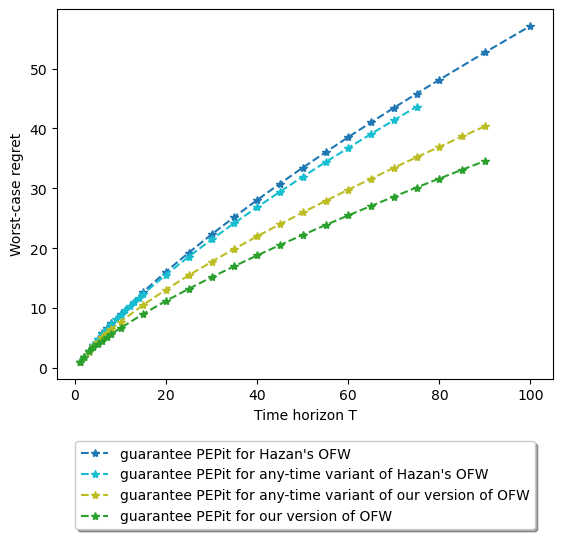

In [20]:
import numpy as np
import matplotlib.pyplot as plt

n_and_tau_to_plot = n_and_pepit_tau_OFW 
N = len(n_and_tau_to_plot)
n_list_to_plot = n_and_tau_to_plot[:N,0]

### Plots

# # Plot 1
# save_dir = '../article/main_OFW_figures/comparison_tau_3'
# plt.plot(n_list_to_plot, [ 8 * n**(3/4) for n in n_list_to_plot], linestyle='-', marker='*', color='tab:red', label="theoretical bound for Hazan's OFW")
# plt.plot(n_and_pepit_tau_OFW[:,0], n_and_pepit_tau_OFW[:,1], linestyle='--', marker='*', color='tab:blue', label="guarantee PEPit for Hazan's OFW")
# plt.plot(n_list_to_plot, [ 4 * (n/3)**(3/4) for n in n_list_to_plot], linestyle='-', marker='*', color='tab:orange', label="theoretical bound for our version of OFW")
# plt.plot(n_and_tau_OFW_our_article[:,0], n_and_tau_OFW_our_article[:,1], linestyle='--', marker='*', color='tab:green', label="guarantee PEPit for our version of OFW")
# plt.plot(n_and_tau_list_OFW_general_optimal_parameters_with_Diam_constraint_and_Constraints_only_next_v_is[:,0], 
#          n_and_tau_list_OFW_general_optimal_parameters_with_Diam_constraint_and_Constraints_only_next_v_is[:,1], 
#          linestyle='--', marker='*', color='tab:purple', label="PEP bound for optimal OFW-type")
# plt.axis((-5,105,-5,105))

# # Plot 2
# save_dir = '../article/main_OFW_figures/comparison_tau_Multi_round'
# plt.plot(n_and_tau_list_OFW_general_optimal_parameters_with_Diam_constraint_and_Constraints_only_next_v_is[:,0], 
#          n_and_tau_list_OFW_general_optimal_parameters_with_Diam_constraint_and_Constraints_only_next_v_is[:,1], 
#          linestyle='--', marker='*', color='tab:purple', label="PEP bound for optimal OFW-type")
# plt.plot(n_and_tau_list_OFW_Multi_Round_q_is_2_general_optimal_parameters_with_Diam_constraint_and_Constraints_only_next_v_is[:,0], 
#          n_and_tau_list_OFW_Multi_Round_q_is_2_general_optimal_parameters_with_Diam_constraint_and_Constraints_only_next_v_is[:,1], 
#          linestyle='--', marker='*', color='tab:brown', label="PEP bound for optimal OFW-type with 2 rounds")
# plt.plot(n_and_tau_list_OFW_Multi_Round_q_is_3_general_optimal_parameters_with_Diam_constraint_and_Constraints_only_next_v_is[:,0], 
#          n_and_tau_list_OFW_Multi_Round_q_is_3_general_optimal_parameters_with_Diam_constraint_and_Constraints_only_next_v_is[:,1], 
#          linestyle='--', marker='*', color='tab:pink', label="PEP bound for optimal OFW-type with 3 rounds")

# # Plot 3
# save_dir = '../article/main_OFW_figures/comparison_tau_unregularised'
# plt.plot(n_and_tau_OFW_without_regulzt_with_opt_param_with_Diam_constraint[:,0], 
#          n_and_tau_OFW_without_regulzt_with_opt_param_with_Diam_constraint[:,1], 
#          linestyle='--', marker='*', color='tab:gray', label="PEP bound for optimal unregularised OFW-type")
# plt.plot(n_and_tau_list_OFW_general_optimal_parameters_with_Diam_constraint_and_Constraints_only_next_v_is[:,0], 
#          n_and_tau_list_OFW_general_optimal_parameters_with_Diam_constraint_and_Constraints_only_next_v_is[:,1], 
#          linestyle='--', marker='*', color='tab:purple', label="PEP bound for optimal OFW-type")

# Plot 4
save_dir = '../article/main_OFW_figures/comparison_tau_any_time'
plt.plot(n_and_pepit_tau_OFW[:,0], n_and_pepit_tau_OFW[:,1], 
         linestyle='--', marker='*', color='tab:blue', label="guarantee PEPit for Hazan's OFW")
plt.plot(n_and_tau_Hazan_OFW_any_time[:,0], n_and_tau_Hazan_OFW_any_time[:,1], 
         linestyle='--', marker='*', color='tab:cyan', label="guarantee PEPit for any-time variant of Hazan's OFW")
plt.plot(n_and_tau_OFW_our_article_any_time[:,0], n_and_tau_OFW_our_article_any_time[:,1], 
         linestyle='--', marker='*', color='tab:olive', label="guarantee PEPit for any-time variant of our version of OFW")
plt.plot(n_and_tau_OFW_our_article[:,0], n_and_tau_OFW_our_article[:,1], 
         linestyle='--', marker='*', color='tab:green', label="guarantee PEPit for our version of OFW")



# plt.legend()
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          fancybox=True, shadow=True)
plt.xlabel('Time horizon T')
plt.ylabel('Worst-case regret')
# plt.axis((-5,105,-5,105))
#plt.loglog()

# fig = plt.figure()
# ax = plt.subplot(111)

# # Shrink current axis's height by 10% on the bottom
# box = ax.get_position()
# ax.set_position([box.x0, box.y0 + box.height * 0.1,
#                  box.width, box.height * 0.9])

# # Put a legend below current axis
# ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
#           fancybox=True, shadow=True, ncol=5)

#plt.show()
import matplot2tikz

matplot2tikz.save(save_dir + ".tex")
plt.savefig(save_dir + ".png")